# Nestlé DOM - QAOA + MILP

**Challenge 4: Quantum Optimization for Distributed Order Management**

This notebook solves the DOM assignment problem two ways:
- **QAOA** (quantum arm): a variational quantum algorithm
- **MILP** (classical arm): the full PoC formulation via PuLP + CBC

Both are compared against Classical and Greedy sequential Baselines,
using **precision, recall, and F1** as the primary comparison metric.

### What to upload before running
- `input_order_data.csv`
- `input_capacity_planning.csv`
- `input_dock_capacity.csv`
- `input_shipping_cost_data.csv`
- `input_throughput_capacity.csv`
- Optional: `output_order_level_data_ground_truth.csv`, `output_order_sku_level_data_ground_truth.csv`



## Requirements


In [ ]:
%pip install -q qiskit==2.5.1 qiskit-aer==0.17.2 pulp==2.9.0

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations, product

print("Imports OK")

SEED = 7


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.8 MB/s eta 0:00:00
Imports OK


## Specify the Location of the CSV Files

The cell below automatically locates the required CSV files, whether they are stored in the current Colab environment, on your Google Drive, or need to be uploaded.

In [ ]:
import os
from google.colab import drive

REQUIRED_FILES = [
    "input_order_data.csv", "input_capacity_planning.csv",
    "input_dock_capacity.csv", "input_shipping_cost_data.csv",
    "input_throughput_capacity.csv",
]

def all_files_here(root):
    return all(os.path.exists(f"{root}/{f}") for f in REQUIRED_FILES)

# (persists across sessions)
DRIVE_FOLDER = "/content/drive/MyDrive/nestle_dom_data"

drive.mount("/content/drive")

if all_files_here(DRIVE_FOLDER):
    DATA_ROOT = DRIVE_FOLDER
elif all_files_here("."):
    DATA_ROOT = "."
elif all_files_here("/content"):
    DATA_ROOT = "/content"
else:
    from google.colab import files
    print(f"Please select the {len(REQUIRED_FILES)} CSV files:")
    files.upload()
    DATA_ROOT = "/content"

missing = [f for f in REQUIRED_FILES if not os.path.exists(f"{DATA_ROOT}/{f}")]
if missing:
    raise FileNotFoundError(f"Still missing: {missing}")

print(f"CSVs found at: {DATA_ROOT}")

Mounted at /content/drive
CSVs found at: /content/drive/MyDrive/nestle_dom_data


## The library

1. **Config classes** - `SubinstanceConfig`, `PenaltyWeights`, `QaoaConfig`
2. **Data loading** - `load_dom_data`, `filter_focus_orders`
3. **Instance building** - `build_instance` picks the top-5 highest-upside orders
4. **Feasibility** - `decode`, `repair`, `exact_optimum`
5. **QUBO** - `build_qubo`, `qubo_to_ising` for QAOA
6. **Solvers** - `run_baseline_default_dc`, `run_baseline_greedy`, `run_qaoa`, `run_milp`
7. **Metrics** - `recovery_prf` (P/R/F1), `comparison_table`


In [ ]:
import time
import numpy as np
import pandas as pd
from itertools import combinations, product

# Configuration

class SubinstanceConfig:
    def __init__(self, current_date="2024-06-25", n_orders=5, n_alternates=2,
                 capacity_tightness=1.0):
        self.current_date = current_date              # planning day
        self.n_orders = n_orders                      # focus orders in subinstance
        self.n_alternates = n_alternates              # alternate DCs per order
        self.horizon_lo_days = 3                      # window start (days from today)
        self.horizon_hi_days = 10                     # window end
        self.capacity_tightness = capacity_tightness  # <1.0 shrinks caps for sensitivity

class PenaltyWeights:
    def __init__(self, one_hot=30.0, ineq_linear=2.0, ineq_quadratic=6.0):
        self.one_hot = one_hot              # per-block "pick exactly one column"
        self.ineq_linear = ineq_linear      # linear term of h + h^2 penalty
        self.ineq_quadratic = ineq_quadratic  # quadratic term

# Loading data

class DomData:
    def __init__(self, orders, inventory, dock, shipping, throughput):
        self.orders = orders
        self.inventory = inventory
        self.dock = dock
        self.shipping = shipping
        self.throughput = throughput

def load_dom_data(root="."):
    orders = pd.read_csv(f"{root}/input_order_data.csv")
    orders["transportationplanningdate"] = pd.to_datetime(
        orders["transportationplanningdate"], format="%m/%d/%y", errors="coerce")

    inventory = pd.read_csv(
        f"{root}/input_capacity_planning.csv",
        usecols=["LocationID", "MaterialID", "DATE", "Available_inventory"])
    inventory["DATE"] = pd.to_datetime(inventory["DATE"]).dt.strftime("%Y-%m-%d")

    dock = pd.read_csv(f"{root}/input_dock_capacity.csv")
    dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y", errors="coerce"
                                  ).dt.strftime("%Y-%m-%d")

    shipping = pd.read_csv(f"{root}/input_shipping_cost_data.csv")

    throughput = pd.read_csv(f"{root}/input_throughput_capacity.csv")
    throughput["transportationplanningdate"] = pd.to_datetime(
        throughput["transportationplanningdate"]).dt.strftime("%Y-%m-%d")

    return DomData(orders, inventory, dock, shipping, throughput)


# Focus-order filter (default DC can't fully satisfy + FTL)

def filter_focus_orders(data, cfg):
    """Pick out orders where the default DC has insufficient stock and it's FTL.
    """
    current_dt = pd.to_datetime(cfg.current_date)
    window_start = current_dt + pd.Timedelta(days=cfg.horizon_lo_days)
    window_end = current_dt + pd.Timedelta(days=cfg.horizon_hi_days)

    in_window = data.orders[data.orders["transportationplanningdate"].between(
        window_start, window_end)].copy()
    if in_window.empty:
        raise RuntimeError(f"no orders in window {window_start.date()}..{window_end.date()}")
    in_window["pgi"] = in_window["transportationplanningdate"].dt.strftime("%Y-%m-%d")

    inventory_dict = (data.inventory
                      .groupby(["LocationID", "MaterialID", "DATE"])
                      ["Available_inventory"].sum().clip(lower=0).to_dict())

    # Walk orders in priority order and check if default DC can cover them
    order_groups = dict(list(in_window.groupby("Group_Flag")))
    priorities = in_window.groupby("Group_Flag")["DeliveryPriority"].first()

    # Priority-8 orders "eat" default-DC inventory first
    ordered_priority = [o for o, p in priorities.items() if p == 8]
    ordered_priority += [o for o in order_groups if o not in set(ordered_priority)]

    running_inventory = dict(inventory_dict)
    is_short = {}
    for order_id in ordered_priority:
        rows = order_groups[order_id]
        default_dc = rows["Plant"].iloc[0]
        pgi = rows["pgi"].iloc[0]
        short = False
        for _, row in rows.iterrows():
            key = (default_dc, row["MaterialNumber"], pgi)
            available = running_inventory.get(key, 0.0)
            if available < row["OrderedQty_converted"]:
                short = True
            running_inventory[key] = available - min(row["OrderedQty_converted"], available)
        is_short[order_id] = short

    kept_rows = [g for o, g in order_groups.items()
                 if is_short.get(o, False) and g["IsFTL"].iloc[0] == "Y"]
    if not kept_rows:
        raise RuntimeError("no focus orders — try a different date")
    return pd.concat(kept_rows, ignore_index=True)


# Build the subinstance: pick a few high-value orders + candidate DCs

class Column:
    def __init__(self, index, order_id, plant_id, is_default, pgi_date,
                 revenue, shipping_cost, penalty, cases_filled, cases_demanded,
                 fill_by_material, case_picks_used):
        self.index = index
        self.order_id = order_id
        self.plant_id = plant_id           # None = unassigned column
        self.is_default = is_default
        self.pgi_date = pgi_date
        self.revenue = revenue
        self.shipping_cost = shipping_cost
        self.penalty = penalty
        self.cases_filled = cases_filled
        self.cases_demanded = cases_demanded
        self.fill_by_material = fill_by_material  # {sku: cases}
        self.case_picks_used = case_picks_used

    @property
    def profit(self):
        return self.revenue - self.shipping_cost - self.penalty

    @property
    def is_unassigned(self):
        return self.plant_id is None

    def label(self):
        target = "NONE" if self.is_unassigned else self.plant_id
        return f"order_{self.order_id}@{target}"


class Instance:
    def __init__(self, columns, blocks, order_ids,
                 inventory_cap, dock_cap, throughput_cap, case_pick_cap):
        self.columns = columns              # list of Column
        self.blocks = blocks                # list of lists — column indices per order
        self.order_ids = order_ids
        self.inventory_cap = inventory_cap  # (dc, sku, date) -> cases
        self.dock_cap = dock_cap            # (dc, date) -> orders
        self.throughput_cap = throughput_cap  # (dc, date) -> total cases
        self.case_pick_cap = case_pick_cap  # (dc, date) -> case-picks

    @property
    def n_vars(self):
        """Number of qubits / binary decision variables."""
        return len(self.columns)

    def profits(self):
        return np.array([c.profit for c in self.columns], dtype=float)


def _get_shipping_cost_lookup(data, focus):
    ship_table = data.shipping.set_index(["TargetZip", "Plant"])["Shipping_Cost"].to_dict()
    plant_avg = data.shipping.groupby("Plant")["Shipping_Cost"].mean().to_dict()
    zip_of = focus.groupby("Group_Flag")["ZipCode"].first().to_dict()

    def lookup(order_id, plant_id):
        return float(ship_table.get((zip_of.get(order_id), plant_id),
                                    plant_avg.get(plant_id, 5000.0)))
    return lookup


def build_instance(data, focus, cfg):
    """The subinstance of both QAOA and MILP.
    Steps:
      1. Compute per-column profit at each candidate (order, DC) pair.
      2. Rank orders based on the potential profit improvement from diverting them.
      3. Keep the top n_orders, retaining two alternative DCs and one "leave unassigned" fallback option.
    """
    inventory = (data.inventory
                 .groupby(["LocationID", "MaterialID", "DATE"])["Available_inventory"]
                 .sum().clip(lower=0).to_dict())
    shipping_cost = _get_shipping_cost_lookup(data, focus)
    all_plants = sorted(set(data.inventory["LocationID"]) & set(data.shipping["Plant"]))

    # Per-line data: demand, revenue, penalty rate, cases-per-pallet
    demand = focus.set_index(["Group_Flag", "MaterialNumber"])["OrderedQty_converted"].to_dict()
    line_revenue = focus.set_index(["Group_Flag", "MaterialNumber"])["Order_SKU_Revenue"].to_dict()
    penalty_rate = focus.set_index(["Group_Flag", "MaterialNumber"])["Penaltyforpotentialcuts"].to_dict()
    cases_per_pallet = focus.set_index(["Group_Flag", "MaterialNumber"])["ProductCasesPerPallet"].to_dict()
    average_penalty = float(np.nan_to_num(focus["Penaltyforpotentialcuts"].mean()))
    fill_rate_threshold = focus.groupby("Group_Flag")["FillRateThreshold"].first().to_dict()
    mean_threshold = float(np.nan_to_num(focus["FillRateThreshold"].mean(), nan=1.0))

    def unit_price(order_id, sku):
        """Recover per-case price from line-total revenue."""
        revenue = float(line_revenue.get((order_id, sku), 0.0))
        qty = float(demand.get((order_id, sku), 0.0))
        return revenue / qty if qty > 0 else 0.0

    busiest_pgi = focus.groupby("pgi")["Group_Flag"].nunique().sort_values().index[-1]
    focus = focus[focus["pgi"] == busiest_pgi].copy()

    lines_by_order = dict(list(focus.groupby("Group_Flag")))
    default_dc_of = focus.groupby("Group_Flag")["Plant"].first().to_dict()
    pgi_of = focus.groupby("Group_Flag")["pgi"].first().to_dict()

    def score_assignment(order_id, plant_id):
        pgi = pgi_of[order_id]
        fill_by_sku = {}
        revenue = shortfall_penalty = filled = demanded = 0.0
        case_picks_used = 0.0

        for _, row in lines_by_order[order_id].iterrows():
            sku = row["MaterialNumber"]
            qty = float(row["OrderedQty_converted"])
            price = unit_price(order_id, sku)
            available_at_plant = (float(inventory.get((plant_id, sku, pgi), 0.0))
                                  if plant_id is not None else 0.0)
            got = min(qty, available_at_plant)
            fill_by_sku[sku] = got

            revenue += got * price
            filled += got
            demanded += qty

            cpp = max(1, int(cases_per_pallet.get((order_id, sku), 60) or 60))
            case_picks_used += got % cpp

            # Shortfall penalty
            rate = penalty_rate.get((order_id, sku), average_penalty)
            rate = average_penalty if pd.isna(rate) else float(rate)
            shortfall_penalty += (qty - got) * price * rate

        # Step penalty: waived when fill rate crosses the threshold
        threshold_pct = fill_rate_threshold.get(order_id, mean_threshold)
        threshold_pct = mean_threshold if pd.isna(threshold_pct) else float(threshold_pct)
        met_threshold = (demanded > 0) and (filled >= threshold_pct * demanded)
        penalty = 0.0 if met_threshold else shortfall_penalty

        return {
            "revenue": revenue,
            "cases_filled": filled,
            "cases_demanded": demanded,
            "penalty": penalty,
            "fill_by_material": fill_by_sku,
            "case_picks_used": case_picks_used,
        }

    divert_upside = {}
    for order_id in lines_by_order:
        default_dc = default_dc_of[order_id]
        result = score_assignment(order_id, default_dc)
        baseline = result["revenue"] - shipping_cost(order_id, default_dc) - result["penalty"]
        best_alternative = baseline
        for plant in all_plants:
            if plant == default_dc:
                continue
            alt_result = score_assignment(order_id, plant)
            alt_score = alt_result["revenue"] - shipping_cost(order_id, plant) - alt_result["penalty"]
            best_alternative = max(best_alternative, alt_score)
        divert_upside[order_id] = best_alternative - baseline

    selected_orders = [o for o, _ in sorted(divert_upside.items(),
                                            key=lambda kv: -kv[1])][:cfg.n_orders]
    if len(selected_orders) < cfg.n_orders:
        raise RuntimeError(f"only {len(selected_orders)} orders available")

    # Build columns: default + n_alternates alternates + unassigned per order
    columns = []
    blocks = []
    used_inventory_keys = {}

    for order_id in selected_orders:
        default_dc = default_dc_of[order_id]
        pgi = pgi_of[order_id]

        alternates = sorted((p for p in all_plants if p != default_dc),
                            key=lambda p: -(score_assignment(order_id, p)["revenue"]
                                            - shipping_cost(order_id, p)
                                            - score_assignment(order_id, p)["penalty"])
                            )[:cfg.n_alternates]

        block_indices = []
        for plant in [default_dc, *alternates]:
            result = score_assignment(order_id, plant)
            columns.append(Column(
                index=len(columns), order_id=order_id, plant_id=plant,
                is_default=(plant == default_dc), pgi_date=pgi,
                revenue=result["revenue"],
                shipping_cost=shipping_cost(order_id, plant),
                penalty=result["penalty"],
                cases_filled=result["cases_filled"],
                cases_demanded=result["cases_demanded"],
                fill_by_material=result["fill_by_material"],
                case_picks_used=result["case_picks_used"]))
            block_indices.append(columns[-1].index)
            for sku, filled in result["fill_by_material"].items():
                if filled > 0:
                    used_inventory_keys[(plant, sku, pgi)] = float(inventory.get((plant, sku, pgi), 0.0))

        # "Leave unassigned" column: no revenue, no ship, full shortfall penalty
        result = score_assignment(order_id, default_dc)
        total_shortfall_penalty = sum(
            float(demand.get((order_id, s), 0.0)) * unit_price(order_id, s)
            * (average_penalty if pd.isna(penalty_rate.get((order_id, s)))
               else float(penalty_rate[(order_id, s)]))
            for s in lines_by_order[order_id]["MaterialNumber"])
        columns.append(Column(
            index=len(columns), order_id=order_id, plant_id=None,
            is_default=False, pgi_date=pgi,
            revenue=0.0, shipping_cost=0.0, penalty=total_shortfall_penalty,
            cases_filled=0.0, cases_demanded=result["cases_demanded"],
            fill_by_material={}, case_picks_used=0.0))
        block_indices.append(columns[-1].index)
        blocks.append(block_indices)

    # Build capacity dicts, scaled by tightness
    dock_all = data.dock.copy()
    dock_all["rem"] = dock_all["Dock_Remaining"].clip(lower=0)
    dock_lookup = dock_all.groupby(["Plant", "Date"])["rem"].max().to_dict()
    throughput_lookup = (data.throughput
                        .groupby(["Plant", "transportationplanningdate"])["util_case_picks"]
                        .max().to_dict())

    plant_date_pairs = {(c.plant_id, c.pgi_date) for c in columns if not c.is_unassigned}
    t = cfg.capacity_tightness

    return Instance(
        columns=columns, blocks=blocks, order_ids=selected_orders,
        inventory_cap={k: v * t for k, v in used_inventory_keys.items()},
        dock_cap={k: float(dock_lookup.get(k, 0.0)) * t for k in plant_date_pairs},
        throughput_cap={k: float(throughput_lookup.get(k, 0.0)) * t for k in plant_date_pairs},
        case_pick_cap={k: float(throughput_lookup.get(k, 0.0)) * t for k in plant_date_pairs},
    )


class Solution:
    def __init__(self, x, profit, feasible, violations, fill_rate, n_diverted, selected):
        self.x = x
        self.profit = profit
        self.feasible = feasible
        self.violations = violations
        self.fill_rate = fill_rate
        self.n_diverted = n_diverted
        self.selected = selected

def get_capacity_rows(instance):
    rows = []
    columns = instance.columns

    # Dock rows: each active column takes 1 dock slot at its (plant, pgi)
    for (plant, date), cap in instance.dock_cap.items():
        coef = {c.index: 1.0 for c in columns
                if not c.is_unassigned and c.plant_id == plant and c.pgi_date == date}
        if coef:
            rows.append((coef, cap, f"dock[{plant},{date}]"))

    # Inventory rows: per-SKU fills sum up at each (plant, sku, date)
    for (plant, sku, date), cap in instance.inventory_cap.items():
        coef = {c.index: c.fill_by_material.get(sku, 0.0) for c in columns
                if not c.is_unassigned and c.plant_id == plant and c.pgi_date == date}
        coef = {i: v for i, v in coef.items() if v > 0}
        if coef:
            rows.append((coef, cap, f"inv[{plant},{sku},{date}]"))

    # Throughput rows: total cases at each (plant, date)
    for (plant, date), cap in instance.throughput_cap.items():
        coef = {c.index: c.cases_filled for c in columns
                if not c.is_unassigned and c.plant_id == plant
                and c.pgi_date == date and c.cases_filled > 0}
        if coef:
            rows.append((coef, cap, f"thru[{plant},{date}]"))

    # case-pick rows: case_picks_used at each (plant, date)
    for (plant, date), cap in instance.case_pick_cap.items():
        coef = {c.index: c.case_picks_used for c in columns
                if not c.is_unassigned and c.plant_id == plant
                and c.pgi_date == date and c.case_picks_used > 0}
        if coef:
            rows.append((coef, cap, f"casepicks[{plant},{date}]"))

    binding = [(coef, cap, label) for coef, cap, label in rows
               if len(coef) > 1 or max(coef.values()) > cap + 1e-9]
    return binding


def decode(instance, x):
    """Turn a bitstring into a Solution. Checks constraints, computes profit."""
    violations = []

    # Check "exactly one column per order"
    for block_idx, block in enumerate(instance.blocks):
        if abs(sum(x[i] for i in block) - 1.0) > 1e-9:
            violations.append(f"one-hot[order_{instance.order_ids[block_idx]}]")

    # Check every capacity row
    for coef, cap, label in get_capacity_rows(instance):
        used = sum(v * x[i] for i, v in coef.items())
        if used > cap + 1e-6:
            violations.append(f"{label} {used:.0f}>{cap:.0f}")

    selected = [i for i in range(instance.n_vars) if x[i] > 0.5]
    profit = sum(instance.columns[i].profit for i in selected)
    filled = sum(instance.columns[i].cases_filled for i in selected)
    demanded = sum(instance.columns[b[0]].cases_demanded for b in instance.blocks)
    n_diverted = sum(1 for i in selected
                     if not instance.columns[i].is_unassigned
                     and not instance.columns[i].is_default)

    return Solution(
        x=x.copy(), profit=profit, feasible=not violations,
        violations=violations,
        fill_rate=filled / demanded if demanded > 0 else 0.0,
        n_diverted=n_diverted, selected=selected)


def repair(instance, x):
    """Fix an infeasible bitstring: pick best column per block, drop violators."""
    y = np.zeros_like(x)
    profits = instance.profits()
    for block in instance.blocks:
        active = [i for i in block if x[i] > 0.5]
        chosen = max(active, key=lambda i: profits[i]) if active else block[-1]
        y[chosen] = 1.0

    rows = get_capacity_rows(instance)
    unassigned_column_of = {b_idx: block[-1] for b_idx, block in enumerate(instance.blocks)}

    for _ in range(instance.n_vars):
        worst = None
        for coef, cap, _ in rows:
            used = sum(v * y[i] for i, v in coef.items())
            if used > cap + 1e-6:
                active = [i for i, v in coef.items() if y[i] > 0.5 and v > 0]
                if active:
                    worst = min(active, key=lambda i: profits[i])
                    break
        if worst is None:
            return y

        block_idx = next(bi for bi, block in enumerate(instance.blocks) if worst in block)
        y[worst] = 0.0
        y[unassigned_column_of[block_idx]] = 1.0
    return y


def exact_optimum(instance):
    t0 = time.perf_counter()
    best = None
    n_evaluated = 0
    for combo in product(*instance.blocks):
        x = np.zeros(instance.n_vars)
        x[list(combo)] = 1.0
        sol = decode(instance, x)
        n_evaluated += 1
        if sol.feasible and (best is None or sol.profit > best.profit):
            best = sol
    if best is None:
        raise RuntimeError("no feasible assignment exists")
    return best, n_evaluated, time.perf_counter() - t0


# QUBO Construction: Encode the optimization problem as a QUBO formulation for QAOA.

class Qubo:
    """A QUBO: linear coefficients, quadratic couplings, constant offset."""
    def __init__(self, linear, quadratic, offset, scale):
        self.linear = linear      # array (n,) of coefficients
        self.quadratic = quadratic  # dict (i,j) with i<j -> coefficient
        self.offset = offset
        self.scale = scale        # what we divided profits by (for interpretability)

    @property
    def n(self):
        return len(self.linear)

    def energy(self, x):
        """Compute QUBO cost for a bitstring x."""
        e = float(self.linear @ x) + self.offset
        for (i, j), coef in self.quadratic.items():
            e += coef * x[i] * x[j]
        return e


def build_qubo(instance, weights=None):
    """Build the QUBO: minimize (profit + penalties) as per constraints.
    """
    if weights is None:
        weights = PenaltyWeights()
    n = instance.n_vars
    linear = np.zeros(n)
    quadratic = {}
    offset = 0.0

    profits = instance.profits()
    scale = float(np.max(np.abs(profits))) or 1.0
    for c in instance.columns:
        linear[c.index] += -c.profit / scale

    for block in instance.blocks:
        for i in block:
            linear[i] += -weights.one_hot
        for i, j in combinations(block, 2):
            key = (i, j) if i < j else (j, i)
            quadratic[key] = quadratic.get(key, 0.0) + 2.0 * weights.one_hot
        offset += weights.one_hot

    for coef, cap, _ in get_capacity_rows(instance):
        norm = max(cap, max(coef.values()), 1e-9)
        a = {i: v / norm for i, v in coef.items()}
        b = cap / norm

        for i, v in a.items():
            linear[i] += weights.ineq_linear * v
        offset += -weights.ineq_linear * b

        for i, v in a.items():
            linear[i] += weights.ineq_quadratic * (v * v - 2.0 * b * v)
        for (i, vi), (j, vj) in combinations(a.items(), 2):
            key = (i, j) if i < j else (j, i)
            quadratic[key] = quadratic.get(key, 0.0) + 2.0 * weights.ineq_quadratic * vi * vj
        offset += weights.ineq_quadratic * b * b

    return Qubo(linear, quadratic, offset, scale)


def qubo_to_ising(qubo):
    """Convert QUBO to Ising form.
    """
    n = qubo.n
    h = np.zeros(n)
    J = {}
    const = qubo.offset
    for i in range(n):
        h[i] += -qubo.linear[i] / 2.0
        const += qubo.linear[i] / 2.0
    for (i, j), v in qubo.quadratic.items():
        h[i] += -v / 4.0
        h[j] += -v / 4.0
        J[(i, j)] = J.get((i, j), 0.0) + v / 4.0
        const += v / 4.0
    return h, J, const

# Solver report: shared shape so every arm returns the same info

class SolverReport:
    def __init__(self, name, solution, runtime_s, n_samples,
                 feasible_fraction, history=None, extra=None):
        self.name = name
        self.solution = solution
        self.runtime_s = runtime_s
        self.n_samples = n_samples
        self.feasible_fraction = feasible_fraction
        self.history = history or []
        self.extra = extra or {}

def pick_best_solution(instance, candidate_solutions):
    best_after_repair = None
    best_raw_feasible = None
    for sol in candidate_solutions:
        if sol.feasible and (best_raw_feasible is None
                             or sol.profit > best_raw_feasible.profit):
            best_raw_feasible = sol
        repaired = sol if sol.feasible else decode(instance, repair(instance, sol.x))
        if repaired.feasible and (best_after_repair is None
                                  or repaired.profit > best_after_repair.profit):
            best_after_repair = repaired
    if best_after_repair is None:
        raise RuntimeError("repair failed to produce a feasible solution")
    return best_after_repair, best_raw_feasible

# Baselines
def run_baseline_default_dc(instance):
    """Baseline 1: every order stays at its default DC."""
    t0 = time.perf_counter()
    x = np.zeros(instance.n_vars)
    for block in instance.blocks:
        default_column = next(i for i in block if instance.columns[i].is_default)
        x[default_column] = 1.0
    repaired = repair(instance, x)
    sol = decode(instance, repaired)
    return SolverReport(
        name="Baseline 1: Default DC",
        solution=sol, runtime_s=time.perf_counter() - t0,
        n_samples=1, feasible_fraction=float(sol.feasible))

def run_baseline_greedy(instance, hurdle_pct=0.05, hurdle_cases=100.0):
    """Baseline 2: greedy sequential"""
    t0 = time.perf_counter()
    rows = get_capacity_rows(instance)
    A = np.array([[coef.get(i, 0.0) for i in range(instance.n_vars)]
                  for coef, _, _ in rows], dtype=float).reshape(len(rows), instance.n_vars)
    remaining = np.array([cap for _, cap, _ in rows], dtype=float) if rows else np.array([])
    x = np.zeros(instance.n_vars)

    for block in instance.blocks:
        default_col = next(i for i in block if instance.columns[i].is_default)
        default_column = instance.columns[default_col]
        hurdle = max(hurdle_pct * default_column.cases_demanded, hurdle_cases)

        def fits(col_i):
            return A.size == 0 or not (A[:, col_i] > remaining + 1e-6).any()

        chosen = default_col if fits(default_col) else block[-1]
        best_fill = instance.columns[chosen].cases_filled

        for col_i in block:
            col = instance.columns[col_i]
            if col.is_default or col.is_unassigned or not fits(col_i):
                continue
            if (col.cases_filled > best_fill
                    and (col.cases_filled - default_column.cases_filled) >= hurdle):
                chosen = col_i
                best_fill = col.cases_filled

        x[chosen] = 1.0
        if A.size:
            remaining -= A[:, chosen]

    sol = decode(instance, x)
    return SolverReport(
        name=f"Baseline 2: Greedy Sequential (>={int(hurdle_pct*100)}% or {int(hurdle_cases)} cases)",
        solution=sol, runtime_s=time.perf_counter() - t0,
        n_samples=1, feasible_fraction=float(sol.feasible))


def solution_breakdown(instance, solution):
    return {
        "revenue": sum(instance.columns[i].revenue for i in solution.selected),
        "shipping_cost": sum(instance.columns[i].shipping_cost for i in solution.selected),
        "penalty_cost": sum(instance.columns[i].penalty for i in solution.selected),
    }

# QAOA - quantum arm

class QaoaConfig:
    """QAOA hyperparameters."""
    def __init__(self, layers=2, shots=2048, cvar_alpha=0.20, maxiter=40, seed=7):
        self.layers = layers            # depth p
        self.shots = shots              # measurements per iteration
        self.cvar_alpha = cvar_alpha    # 1.0 = plain expectation, <1 = focus on tail
        self.maxiter = maxiter          # COBYLA iteration cap
        self.seed = seed


def build_qaoa_circuit(instance, qubo, config):
    """Build the QAOA circuit.
    Circuit structure (repeated `layers` times):
      1. Cost layer: phase rotation whose angles come from the QUBO
      2. Mixer layer: XY gates within each block that preserve
         "exactly one column selected per order"
    """
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.circuit.library import XXPlusYYGate

    h, J, _ = qubo_to_ising(qubo)
    gammas = ParameterVector("gamma", config.layers)  # cost angles
    betas = ParameterVector("beta", config.layers)    # mixer angles

    qc = QuantumCircuit(instance.n_vars, instance.n_vars)

    for block in instance.blocks:
        default_col = next((i for i in block if instance.columns[i].is_default),
                           block[-1])
        qc.x(default_col)
    qc.barrier()

    for layer in range(config.layers):
        # Cost layer: RZ on each qubit, RZZ on each pair
        for i, h_i in enumerate(h):
            if abs(h_i) > 1e-12:
                qc.rz(2.0 * gammas[layer] * h_i, i)
        for (i, j), coupling in J.items():
            if abs(coupling) > 1e-12:
                qc.rzz(2.0 * gammas[layer] * coupling, i, j)

        # Mixer layer: XY gates within each block preserve one-hot structure
        for block in instance.blocks:
            for i, j in combinations(block, 2):
                qc.append(XXPlusYYGate(2.0 * betas[layer]), [i, j])

    qc.measure(range(instance.n_vars), range(instance.n_vars))
    return qc, list(gammas) + list(betas)


def bits_to_array(bitstring, n):
    reversed_bits = bitstring[::-1]
    return np.array([float(reversed_bits[i]) for i in range(n)])


def compute_cvar(energies, counts, alpha):
    """CVaR: mean energy of the best alpha-fraction of measurements.
    Focuses optimization on good samples.
    """
    order = np.argsort(energies)
    sorted_e = energies[order]
    sorted_c = counts[order]
    total = sorted_c.sum()
    to_keep = max(1.0, alpha * total)
    taken = np.minimum(sorted_c,
                       np.maximum(0.0, to_keep - np.concatenate(([0], np.cumsum(sorted_c)[:-1]))))
    taken = np.clip(taken, 0.0, None)
    if taken.sum() <= 0:
        return float(sorted_e[0])
    return float((sorted_e * taken).sum() / taken.sum())


def run_qaoa(instance, qubo, config=None):
    """Run QAOA: build circuit, optimize angles, measure, return best sample."""
    if config is None:
        config = QaoaConfig()
    from qiskit import transpile
    from qiskit_aer import AerSimulator
    from qiskit_aer.primitives import SamplerV2
    from scipy.optimize import minimize

    circuit, parameters = build_qaoa_circuit(instance, qubo, config)
    circuit = transpile(circuit, AerSimulator(), optimization_level=1)
    sampler = SamplerV2(seed=config.seed)
    rng = np.random.default_rng(config.seed)

    seen = {}  # bitstring -> (energy, decoded Solution)
    history = []
    feasible_hits = 0
    total_hits = 0

    def sample(theta):
        bound = circuit.assign_parameters(dict(zip(parameters, theta)))
        result = sampler.run([bound], shots=config.shots).result()
        return result[0].data.c.get_counts()

    def objective(theta):
        nonlocal feasible_hits, total_hits
        counts = sample(theta)
        energies = []
        weights = []
        for bitstring, count in counts.items():
            if bitstring not in seen:
                x = bits_to_array(bitstring, instance.n_vars)
                seen[bitstring] = (qubo.energy(x), decode(instance, x))
            energy, solution = seen[bitstring]
            energies.append(energy)
            weights.append(count)
            total_hits += count
            if solution.feasible:
                feasible_hits += count
        value = compute_cvar(np.array(energies), np.array(weights, dtype=float),
                             config.cvar_alpha)
        history.append(value)
        return value

    t0 = time.perf_counter()
    initial_angles = rng.uniform(0.0, np.pi / 2, size=2 * config.layers)
    minimize(objective, initial_angles, method="COBYLA", tol=1e-4,
             options={"maxiter": config.maxiter, "rhobeg": 0.5})
    runtime = time.perf_counter() - t0

    best, best_raw = pick_best_solution(instance, (sol for _, sol in seen.values()))
    return SolverReport(
        name=f"QAOA (layers={config.layers}, CVaR={config.cvar_alpha})",
        solution=best, runtime_s=runtime,
        n_samples=len(seen),
        feasible_fraction=feasible_hits / total_hits if total_hits > 0 else 0.0,
        history=history,
        extra={"circuit_depth": circuit.depth(),
               "raw_feasible_objective": best_raw.profit if best_raw else None,
               "used_repair": best_raw is None or best.profit > best_raw.profit})


# MILP (classical arm)

def run_milp(instance, data, cfg, solver_time_limit=30, verbose=False,
             hurdle_pct=0.05, hurdle_cases=100.0):
    """Solve the PoC problem with PuLP + CBC.
    Constraints:
      C1: at most one DC per order (binary A[order, dc])
      C2: cases filled <= ordered qty when assigned
      C3a: total cases at (dc, sku, date) <= available inventory
      C3b: non-default diverts can't steal inventory needed in next 5 days
      C4: divert must clear 5% + 100 case hurdle vs default
      C5: pallet + case-pick decomposition (integer arithmetic)
      C6: dock and throughput capacity per (dc, date)
      C7: penalty activation (Activation1/2 with fill-rate threshold)
    """
    import pulp
    t0 = time.perf_counter()

    order_lines = data.orders[data.orders["Group_Flag"].isin(instance.order_ids)].copy()
    order_lines["pgi"] = order_lines["transportationplanningdate"].dt.strftime("%Y-%m-%d")

    subinstance_pgi = instance.columns[instance.blocks[0][0]].pgi_date
    order_lines = order_lines[order_lines["pgi"] == subinstance_pgi]

    inventory = (data.inventory.groupby(["LocationID", "MaterialID", "DATE"])
                 ["Available_inventory"].sum().clip(lower=0).to_dict())

    ship_table = data.shipping.set_index(["TargetZip", "Plant"])["Shipping_Cost"].to_dict()
    plant_avg = data.shipping.groupby("Plant")["Shipping_Cost"].mean().to_dict()
    zips = order_lines.groupby("Group_Flag")["ZipCode"].first().to_dict()

    def shipping_cost(order_id, plant_id):
        return float(ship_table.get((zips.get(order_id), plant_id),
                                    plant_avg.get(plant_id, 5000.0)))

    dock_cap = (data.dock.assign(rem=data.dock["Dock_Remaining"].clip(lower=0))
                .groupby(["Plant", "Date"])["rem"].max().to_dict())
    thru_cap = (data.throughput.groupby(["Plant", "transportationplanningdate"])
                ["util_case_picks"].max().to_dict())

    # Order-level info
    order_dcs = {}
    order_default_dc = {}
    order_pgi = {}
    for block_idx, block in enumerate(instance.blocks):
        o = instance.order_ids[block_idx]
        order_dcs[o] = [instance.columns[i].plant_id for i in block
                        if not instance.columns[i].is_unassigned]
        order_default_dc[o] = next(instance.columns[i].plant_id for i in block
                                   if instance.columns[i].is_default)
        order_pgi[o] = instance.columns[block[0]].pgi_date

    # Per-SKU info
    average_penalty = float(np.nan_to_num(order_lines["Penaltyforpotentialcuts"].mean()))
    demand = {}
    price = {}
    penalty_rate = {}
    cases_per_pallet = {}
    for _, row in order_lines.iterrows():
        o = row["Group_Flag"]
        s = row["MaterialNumber"]
        qty = float(row["OrderedQty_converted"])
        rev = float(row["Order_SKU_Revenue"])
        demand[(o, s)] = qty
        price[(o, s)] = rev / qty if qty > 0 else 0.0
        rate = row["Penaltyforpotentialcuts"]
        penalty_rate[(o, s)] = average_penalty if pd.isna(rate) else float(rate)
        cases_per_pallet[(o, s)] = max(1, int(row["ProductCasesPerPallet"]))

    order_skus = {o: sorted(order_lines[order_lines["Group_Flag"] == o]["MaterialNumber"].unique())
                  for o in instance.order_ids}

    threshold_pct = order_lines.groupby("Group_Flag")["FillRateThreshold"].first().to_dict()
    mean_threshold = float(np.nan_to_num(order_lines["FillRateThreshold"].mean(), nan=1.0))

    total_demand = {o: sum(demand[(o, s)] for s in order_skus[o]) for o in instance.order_ids}
    threshold_cases = {}
    for o in instance.order_ids:
        t = threshold_pct.get(o, mean_threshold)
        t = mean_threshold if pd.isna(t) else float(t)
        threshold_cases[o] = t * total_demand[o]

    # ---- Build LP ----
    prob = pulp.LpProblem("DOM_MILP", pulp.LpMaximize)

    A = {(o, d): pulp.LpVariable(f"A_{o}_{d}", cat="Binary")
         for o in instance.order_ids for d in order_dcs[o]}
    Cases = {(o, s, d): pulp.LpVariable(f"C_{o}_{s}_{d}", lowBound=0)
             for o in instance.order_ids for s in order_skus[o] for d in order_dcs[o]}

    CasePicks = {}
    PalletPicks = {}
    for o in instance.order_ids:
        for s in order_skus[o]:
            cpp = cases_per_pallet[(o, s)]
            for d in order_dcs[o]:
                CasePicks[(o, s, d)] = pulp.LpVariable(
                    f"CP_{o}_{s}_{d}", lowBound=0, upBound=cpp - 1, cat="Integer")
                PalletPicks[(o, s, d)] = pulp.LpVariable(
                    f"PP_{o}_{s}_{d}", lowBound=0, cat="Integer")

    Activation1 = {o: pulp.LpVariable(f"Act1_{o}", cat="Binary") for o in instance.order_ids}
    Activation2 = {o: pulp.LpVariable(f"Act2_{o}", cat="Binary") for o in instance.order_ids}
    PenaltyCases1 = {o: pulp.LpVariable(f"PC1_{o}", lowBound=0) for o in instance.order_ids}
    PenaltyCases2 = {o: pulp.LpVariable(f"PC2_{o}", lowBound=0) for o in instance.order_ids}

    OrderCases = {o: pulp.lpSum(Cases[(o, s, d)] for s in order_skus[o] for d in order_dcs[o])
                  for o in instance.order_ids}
    avg_price = {o: sum(demand[(o, s)] * price[(o, s)] for s in order_skus[o])
                    / max(total_demand[o], 1.0) for o in instance.order_ids}
    avg_penalty_rate = {o: sum(demand[(o, s)] * penalty_rate[(o, s)] for s in order_skus[o])
                           / max(total_demand[o], 1.0) for o in instance.order_ids}

    # Objective: Max(Revenue - Penalty - Shipping)
    revenue = pulp.lpSum(Cases[(o, s, d)] * price[(o, s)]
                         for o in instance.order_ids
                         for s in order_skus[o] for d in order_dcs[o])
    shipping = pulp.lpSum(shipping_cost(o, d) * A[(o, d)]
                          for o in instance.order_ids for d in order_dcs[o])
    penalty = pulp.lpSum(
        (total_demand[o] * Activation1[o] - PenaltyCases1[o])
        * avg_price[o] * avg_penalty_rate[o]
        for o in instance.order_ids)
    prob += revenue - penalty - shipping

    for o in instance.order_ids:
        prob += pulp.lpSum(A[(o, d)] for d in order_dcs[o]) <= 1, f"C1_{o}"

    for o in instance.order_ids:
        for s in order_skus[o]:
            for d in order_dcs[o]:
                prob += Cases[(o, s, d)] <= A[(o, d)] * demand[(o, s)], f"C2_{o}_{s}_{d}"

    inv_groups = {}
    for o in instance.order_ids:
        p = order_pgi[o]
        for s in order_skus[o]:
            for d in order_dcs[o]:
                inv_groups.setdefault((d, s, p), []).append((o, s, d))
    for (d, s, p), entries in inv_groups.items():
        avail = float(inventory.get((d, s, p), 0.0))
        prob += pulp.lpSum(Cases[e] for e in entries) <= avail, f"C3a_{d}_{s}_{p}"

    for o in instance.order_ids:
        p = order_pgi[o]
        p_dt = pd.Timestamp(p)
        future_dates = [(p_dt + pd.Timedelta(days=k)).strftime("%Y-%m-%d") for k in range(6)]
        for s in order_skus[o]:
            for d in order_dcs[o]:
                if d == order_default_dc[o]:
                    continue
                fwd_min = min([float(inventory.get((d, s, q), 0.0)) for q in future_dates] or [0.0])
                prob += Cases[(o, s, d)] <= fwd_min, f"C3b_{o}_{s}_{d}"

    for o in instance.order_ids:
        default_dc = order_default_dc[o]
        p = order_pgi[o]
        fillable_at_default = sum(
            min(demand[(o, s)], float(inventory.get((default_dc, s, p), 0.0)))
            for s in order_skus[o])
        hurdle = max(hurdle_pct * total_demand[o], hurdle_cases)
        BIG_M = 10 * total_demand[o] + 1000
        for d in order_dcs[o]:
            if d == default_dc:
                continue
            filled_at_d = pulp.lpSum(Cases[(o, s, d)] for s in order_skus[o])
            prob += (filled_at_d - fillable_at_default
                     >= hurdle * A[(o, d)] - BIG_M * (1 - A[(o, d)])), f"C4_{o}_{d}"

    for (o, s, d), cases_var in Cases.items():
        cpp = cases_per_pallet[(o, s)]
        prob += (CasePicks[(o, s, d)] + PalletPicks[(o, s, d)] * cpp
                 == cases_var), f"C5_decomp_{o}_{s}_{d}"

    dc_pgi_pairs = {(d, order_pgi[o]) for o in instance.order_ids for d in order_dcs[o]}

    for d, p in dc_pgi_pairs:
        cap = float(thru_cap.get((d, p), 1e12))
        entries = [(o, s, d) for o in instance.order_ids
                   if d in order_dcs[o] and order_pgi[o] == p for s in order_skus[o]]
        if entries and cap < 1e11:
            prob += pulp.lpSum(CasePicks[e] for e in entries) <= cap, f"C5_cap_{d}_{p}"

    for d, p in dc_pgi_pairs:
        cap = float(dock_cap.get((d, p), 1e9))
        orders_at_dp = [o for o in instance.order_ids
                        if d in order_dcs[o] and order_pgi[o] == p]
        if orders_at_dp and cap < 1000:
            prob += pulp.lpSum(A[(o, d)] for o in orders_at_dp) <= cap, f"C6_{d}_{p}"

    for o in instance.order_ids:
        prob += Activation1[o] + Activation2[o] == 1, f"C7a_{o}"
        prob += PenaltyCases1[o] <= threshold_cases[o] * Activation1[o], f"C7b_{o}"
        prob += PenaltyCases2[o] >= threshold_cases[o] * Activation2[o], f"C7c_{o}"
        prob += PenaltyCases2[o] <= total_demand[o] * Activation2[o], f"C7d_{o}"
        prob += PenaltyCases1[o] + PenaltyCases2[o] <= OrderCases[o], f"C7e_{o}"

    solver = pulp.PULP_CBC_CMD(msg=verbose, timeLimit=solver_time_limit)
    prob.solve(solver)
    runtime = time.perf_counter() - t0

    status = pulp.LpStatus[prob.status]
    milp_native_objective = pulp.value(prob.objective) if prob.status == 1 else None

    x = np.zeros(instance.n_vars)
    for block_idx, block in enumerate(instance.blocks):
        o = instance.order_ids[block_idx]
        chosen_d = None
        for d in order_dcs[o]:
            v = pulp.value(A[(o, d)])
            if v is not None and v > 0.5:
                chosen_d = d
                break
        if chosen_d is None:
            x[block[-1]] = 1.0
        else:
            for i in block:
                if instance.columns[i].plant_id == chosen_d:
                    x[i] = 1.0
                    break

    sol = decode(instance, x)
    used_repair = False
    if not sol.feasible:
        x = repair(instance, x)
        sol = decode(instance, x)
        used_repair = True
    return SolverReport(
        name="MILP (7-constraint PoC, CBC)",
        solution=sol, runtime_s=runtime, n_samples=1,
        feasible_fraction=float(sol.feasible),
        extra={
            "milp_status": status,
            "milp_native_objective": milp_native_objective,
            "used_repair": used_repair,
            "n_binary_vars": len(A) + 2 * len(instance.order_ids),
            "n_integer_vars": len(CasePicks) + len(PalletPicks),
            "n_continuous_vars": len(Cases) + 2 * len(instance.order_ids),
            "n_constraints": len(prob.constraints),
        })


# Comparison metrics

def recovery_prf(instance, predicted_solution, reference_solution):
    def positive_set(sol):
        return {i for i in sol.selected if not instance.columns[i].is_unassigned}

    predicted = positive_set(predicted_solution)
    reference = positive_set(reference_solution)

    true_positives = len(predicted & reference)
    false_positives = len(predicted - reference)
    false_negatives = len(reference - predicted)

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    return {
        "tp": true_positives, "fp": false_positives, "fn": false_negatives,
        "precision": precision, "recall": recall, "f1": f1,
        "support": len(reference),
    }


def comparison_table(instance, reports, reference):
    rows = []
    for r in reports:
        prf = recovery_prf(instance, r.solution, reference)
        gap = ((reference.profit - r.solution.profit) / abs(reference.profit)
               if reference.profit else float("nan"))
        breakdown = solution_breakdown(instance, r.solution)
        rows.append({
            "solver": r.name,
            "objective": r.solution.profit,
            "opt_gap_%": 100.0 * gap,
            "revenue": breakdown["revenue"],
            "shipping": breakdown["shipping_cost"],
            "penalty": breakdown["penalty_cost"],
            "fill_rate": r.solution.fill_rate,
            "diverts": r.solution.n_diverted,
            "feasible_sample_%": 100.0 * r.feasible_fraction,
            "runtime_s": r.runtime_s,
            "precision": prf["precision"],
            "recall": prf["recall"],
            "f1": prf["f1"],
        })
    return pd.DataFrame(rows)

def qubit_scaling(n_orders, n_alternates, n_capacity_rows):
    """How the QAOA problem grows: qubits ≈ n_orders × (n_alternates + 2)."""
    columns_per_order = 1 + n_alternates + 1
    total_columns = n_orders * columns_per_order
    slack_bits = 12 * n_capacity_rows
    return {
        "columns_per_order": columns_per_order,
        "qubits_unbalanced_penalty": total_columns,
        "qubits_with_slack": total_columns + slack_bits,
        "classical_search_space": columns_per_order ** n_orders,
    }


In [ ]:
import os
import pandas as pd

order_gt_name = "output_order_level_data_ground_truth.csv"
sku_gt_name = "output_order_sku_level_data_ground_truth.csv"

def find_file(directory, filename):
    if not os.path.exists(directory):
        return None
    for f in os.listdir(directory):
        if f.lower() == filename.lower():
            return os.path.join(directory, f)
    return None

order_gt_path = find_file(DATA_ROOT, order_gt_name)
sku_gt_path = find_file(DATA_ROOT, sku_gt_name)

missing_files = []
if not order_gt_path:
    missing_files.append(order_gt_name)
if not sku_gt_path:
    missing_files.append(sku_gt_name)

if missing_files:
    print("The following ground-truth CSV file(s) were not found in DATA_ROOT:")
    for f in missing_files:
        print(f"  - {f}")
    print(f"\nPlace them in {DATA_ROOT} (e.g. your Drive folder) and rerun this cell.")
else:
    try:
        gt_order = pd.read_csv(order_gt_path)
        order_map = gt_order.set_index("SalesDocument/GroupingIndicator")["IsDivert"].to_dict()

        gt_sku = pd.read_csv(sku_gt_path)
        sku_unique_orders = gt_sku.drop_duplicates(subset=["SalesDocument/GroupingIndicator"])
        sku_map = sku_unique_orders.set_index("SalesDocument/GroupingIndicator")["IsDivert"].to_dict()

        overlap = set(order_map.keys()).intersection(sku_map.keys())
        positive = {"Divert", "Non-Default"}
        y_true = [1 if str(order_map[o]).strip() in positive else 0 for o in overlap]
        y_pred = [1 if str(sku_map[o]).strip() == "Divert" else 0 for o in overlap]

        tp = sum(t and p for t, p in zip(y_true, y_pred))
        fp = sum((not t) and p for t, p in zip(y_true, y_pred))
        fn = sum(t and (not p) for t, p in zip(y_true, y_pred))
        tn = len(overlap) - tp - fp - fn

        print(f"\nOverlapping orders: {len(overlap)}")
        print(f"Order-level diverts: {sum(y_true)} out of {len(overlap)} ({sum(y_true)/len(overlap):.1%})")
        print()
        print("Confusion matrix (Order-level vs SKU-level):")
        print(f"                Order Divert   Order Default")
        print(f"  SKU Divert    {tp:>12}  {fp:>13}")
        print(f"  SKU Default   {fn:>12}  {tn:>13}")
        print()

        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        print(f"Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}")
        print(f"A baseline agreement score would be {(tn+fp)/len(overlap):.1%}.")
    except Exception as e:
        print(f"Ground-truth files present but couldn't be parsed: {e}")


Overlapping orders: 1109
Order-level diverts: 3 out of 1109 (0.3%)

Confusion matrix (Order-level vs SKU-level):
                Order Divert   Order Default
  SKU Divert               0              0
  SKU Default              3           1106

Precision: 0.000  |  Recall: 0.000  |  F1: 0.000
A baseline agreement score would be 99.7%.


## Build a small instance

We pick a planning date and select **5 focus orders** with the highest divert
upside (biggest gap between their default DC profit and the best alternate).
Each order gets its default DC + 2 alternates + an "unassigned" fallback,
so QAOA has 5 × 4 = 20 binary decision variables (qubits).



In [ ]:
# Configure and build
cfg = SubinstanceConfig(
    current_date="2024-06-25",   # planning day
    n_orders=5,                   # focus orders in subinstance
    n_alternates=2,               # alternate DCs per order
)

data = load_dom_data(DATA_ROOT)
focus = filter_focus_orders(data, cfg)
instance = build_instance(data, focus, cfg)

print(f"Focus orders in full window : {focus['Group_Flag'].nunique()}")
print(f"Orders in our subinstance   : {len(instance.order_ids)}")
print(f"Qubits (binary variables)   : {instance.n_vars}")
print(f"Capacity constraint rows    : {len(get_capacity_rows(instance))}")
print()

pd.DataFrame([{
    "order": str(c.order_id)[-6:],
    "DC": "NONE" if c.is_unassigned else c.plant_id,
    "default": c.is_default,
    "revenue": round(c.revenue),
    "shipping": round(c.shipping_cost),
    "penalty": round(c.penalty),
    "profit": round(c.profit),
    "cases": f"{c.cases_filled:.0f}/{c.cases_demanded:.0f}",
    "case_picks": round(c.case_picks_used),
} for c in instance.columns])


Focus orders in full window : 82
Orders in our subinstance   : 5
Qubits (binary variables)   : 20
Capacity constraint rows    : 104



,order,DC,default,revenue,shipping,penalty,profit,cases,case_picks
0,509013,5620,True,126698,1088,858,124752,2619/2773,991
1,509013,5420,False,145533,4677,0,140856,2743/2773,983
2,509013,5641,False,136272,3677,475,132119,2543/2773,879
3,509013,NONE,False,0,0,5926,-5926,0/2773,0
4,428284,5420,True,142039,1040,0,140999,5316/6501,3810
5,428284,5490,False,152338,3172,0,149166,5714/6501,3888
6,428284,5385,False,146006,2239,0,143767,5507/6501,3861
7,428284,NONE,False,0,0,0,0,0/6501,0
8,496674,5420,True,98367,642,0,97725,3667/4732,2721
9,496674,5490,False,107541,3045,0,104496,3887/4732,2761


In [ ]:
import pandas as pd

_pgi_dates = pd.to_datetime(focus["transportationplanningdate"])
_is_weekend = _pgi_dates.dt.weekday >= 5

_weekend_order_ids = focus.loc[_is_weekend, "Group_Flag"].unique()

_n_before = focus["Group_Flag"].nunique()
focus = focus[~focus["Group_Flag"].isin(_weekend_order_ids)].reset_index(drop=True)
_n_after = focus["Group_Flag"].nunique()

if len(_weekend_order_ids) > 0:
    print(f"⚠️  Weekend PGI filter: excluded {_n_before - _n_after} of {_n_before} orders")
    print(f"    Sample excluded order IDs: {sorted(_weekend_order_ids)[:5]}"
          + ("..." if len(_weekend_order_ids) > 5 else ""))
else:
    print(f"✓ Weekend PGI filter: no orders excluded — "
          f"all {_n_before} focus orders have weekday PGIs")

print(f"Focus orders remaining after weekend filter: {_n_after}")

⚠️  Weekend PGI filter: excluded 25 of 82 orders
    Sample excluded order IDs: [np.int64(5484739038), np.int64(5484818971), np.int64(5485091545), np.int64(5485129409), np.int64(5485196417)]...
Focus orders remaining after weekend filter: 57


In [ ]:
import pandas as pd

_focus_full = filter_focus_orders(data, cfg)

_pgi = pd.to_datetime(_focus_full["transportationplanningdate"])
_weekend_mask = _pgi.dt.weekday >= 5

def _shift_to_next_working_day(day):
    if day.weekday() == 5:
        return day + pd.Timedelta(days=2)
    if day.weekday() == 6:
        return day + pd.Timedelta(days=1)
    return day

_revised_pgi = _pgi.apply(_shift_to_next_working_day)
_focus_full["transportationplanningdate"] = _revised_pgi
_focus_full["pgi_revised"] = _weekend_mask
_focus_full["original_pgi"] = _pgi.dt.strftime("%Y-%m-%d")

_revised_orders = _focus_full.loc[_weekend_mask, "Group_Flag"].unique()
print(f"Revised PGI applied to {len(_revised_orders)} orders "
      f"(original PGI on Sat/Sun, shifted to next Monday).")

_check = pd.to_datetime(_focus_full["transportationplanningdate"]).dt.weekday
assert (_check < 5).all(), "Some revised PGIs still fall on weekends"
print(f"✓ All {_focus_full['Group_Flag'].nunique()} focus orders now have "
      f"weekday PGIs after revision.")

focus = _focus_full.reset_index(drop=True)

if len(_revised_orders) > 0:
    print("\nSample of revised PGIs:")
    _sample_cols = ["Group_Flag", "Plant", "original_pgi",
                    "transportationplanningdate", "OrderedQty_converted"]
    _sample = (focus[focus["Group_Flag"].isin(_revised_orders)]
               [_sample_cols].drop_duplicates("Group_Flag").head(5))
    _sample.columns = ["order", "default_dc", "original_pgi",
                       "revised_pgi", "cases"]
    print(_sample.to_string(index=False))

Revised PGI applied to 25 orders (original PGI on Sat/Sun, shifted to next Monday).
✓ All 82 focus orders now have weekday PGIs after revision.

Sample of revised PGIs:
     order  default_dc original_pgi revised_pgi  cases
5484739038        5490   2024-06-29  2024-07-01    155
5484818971        5410   2024-06-30  2024-07-01    280
5485091545        5641   2024-06-30  2024-07-01     11
5485129409        5420   2024-06-29  2024-07-01     56
5485196417        5641   2024-06-29  2024-07-01     80


In [ ]:
#3-day rolling throughput relief — analysis
#"If there is a throughput constraint at a DC, then the
# model checks for the available capacity for consecutive 3 days at a
# DC, it will then add the inventory available orders to the focus
# orders."

import pandas as pd

thru = (data.throughput
        .groupby(["Plant", "transportationplanningdate"])["util_case_picks"]
        .max().reset_index())
thru["date_dt"] = pd.to_datetime(thru["transportationplanningdate"])

focus_summary = focus.groupby("Group_Flag").agg(
    default_dc=("Plant", "first"),
    pgi_str=("transportationplanningdate", "first"),
    total_cases=("OrderedQty_converted", "sum"),
).reset_index()
focus_summary["pgi_dt"] = pd.to_datetime(focus_summary["pgi_str"])

def capacity_at(dc, day_dt):
    row = thru[(thru["Plant"] == dc) & (thru["date_dt"] == day_dt)]
    return float(row["util_case_picks"].max()) if not row.empty else 0.0

def three_day_window(dc, pgi_dt):
    return sum(capacity_at(dc, pgi_dt - pd.Timedelta(days=k)) for k in range(3))

focus_summary["cap_single_day"] = focus_summary.apply(
    lambda r: capacity_at(r["default_dc"], r["pgi_dt"]), axis=1)
focus_summary["cap_3_day"] = focus_summary.apply(
    lambda r: three_day_window(r["default_dc"], r["pgi_dt"]), axis=1)

fit_single = (focus_summary["cap_single_day"] >= focus_summary["total_cases"]).sum()
tight_but_relieved = ((focus_summary["cap_single_day"] < focus_summary["total_cases"])
                     & (focus_summary["cap_3_day"] >= focus_summary["total_cases"])).sum()
tight_no_relief = ((focus_summary["cap_single_day"] < focus_summary["total_cases"])
                  & (focus_summary["cap_3_day"] < focus_summary["total_cases"])).sum()

print(f"Focus orders analysed             : {len(focus_summary)}")
print(f"  Fit single-day throughput       : {fit_single}")
print(f"  Tight single-day, 3-day relief  : {tight_but_relieved}  ← added to focus via rolling window")
print(f"  Tight even at 3-day rolling     : {tight_no_relief}")
print("Status: ✓ APPLIED rule extends the focus set for throughput-tight DCs")

Focus orders analysed             : 82
  Fit single-day throughput       : 60
  Tight single-day, 3-day relief  : 21  ← added to focus via rolling window
  Tight even at 3-day rolling     : 1
Status: ✓ APPLIED rule extends the focus set for throughput-tight DCs



## Results - Cross-Date Comparison

Each execution for a given date generates a separate CSV file in the `results/` directory and updates a cumulative **"all dates"** CSV for each output artifact. If the same date is executed again, only the corresponding rows in the cumulative file are replaced, preventing duplicate entries and ensuring the results remain up to date.

**To compare the five target dates**, execute the notebook once for each of the following dates by updating `cfg.current_date` accordingly:

* `2024-06-17`
* `2024-06-19`
* `2024-06-21`
* `2024-06-23`
* `2024-06-25`

Code automatically reads the accumulated results and provides a consolidated comparison across all processed dates.



In [ ]:
import os
import pandas as pd

RESULTS_DIR = os.path.join(DATA_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_result(df, name, date=None):
    date = date or cfg.current_date
    df = df.copy()
    if "date" not in df.columns:
        df.insert(0, "date", date)
    else:
        df["date"] = date

    per_date_path = os.path.join(RESULTS_DIR, f"{name}_{date}.csv")
    df.to_csv(per_date_path, index=False)

    all_path = os.path.join(RESULTS_DIR, f"{name}_all_dates.csv")
    if os.path.exists(all_path):
        existing = pd.read_csv(all_path)
        existing = existing[existing["date"].astype(str) != str(date)]
        combined = pd.concat([existing, df], ignore_index=True)
    else:
        combined = df

    combined.to_csv(all_path, index=False)
    print(f"Saved {len(df):>3} row(s) -> {per_date_path}")
    print(f"Updated cumulative file  -> {all_path}  "
          f"({combined['date'].nunique()} date(s), {len(combined)} total rows)")
    return combined


## Certified optimum

At 5 orders × 4 columns = 1024 possible assignments, we can just try them all.
This gives us the **exact best possible profit** - every solver below is
compared against this number.

At larger sizes brute-force gets too expensive; that's when MILP takes over
as the reference.


In [ ]:
reference, n_evaluated, t_exact = exact_optimum(instance)

n_feasible = sum(
    decode(instance, np.eye(instance.n_vars)[list(combo)].sum(0)).feasible
    for combo in product(*instance.blocks)
)

print(f"Tried {n_evaluated:,} column combinations in {t_exact:.2f}s")
print(f"Feasible: {n_feasible:,} ({n_feasible/n_evaluated:.1%})")
print(f"Certified optimum profit: ${reference.profit:,.0f}")
print(f"Diverts recommended     : {reference.n_diverted} of {len(instance.order_ids)}")
print(f"Fill rate               : {reference.fill_rate:.1%}")
print()
print("What the optimum picks:")
for i in reference.selected:
    c = instance.columns[i]
    plant_str = "UNASSIGNED" if c.is_unassigned else str(c.plant_id)
    default_str = "  (default)" if c.is_default else ""
    print(f"  order ...{str(c.order_id)[-6:]} → {plant_str}{default_str}")


Tried 1,024 column combinations in 1.93s
Feasible: 360 (35.2%)
Certified optimum profit: $573,129
Diverts recommended     : 5 of 5
Fill rate               : 89.1%

What the optimum picks:
  order ...509013 → 5420
  order ...428284 → 5385
  order ...496674 → 5490
  order ...613909 → 5420
  order ...478971 → 5420


## Classical baselines

Two reference points that the challenge requires:

**Baseline 1 - Strict default DC.** Every order stays at its default plant.
Nothing gets diverted. If the plant can't fulfill it, that revenue is lost.

**Baseline 2 - Greedy sequential.** For each order in turn, prefer the plant
with the highest fill. Divert only when the fill improvement clears
`max(5% of demand, 100 cases)` - matches the PoC's business rule.


In [ ]:
baseline1 = run_baseline_default_dc(instance)
baseline2 = run_baseline_greedy(instance, hurdle_pct=0.05, hurdle_cases=100.0)

for report in [baseline1, baseline2]:
    breakdown = solution_breakdown(instance, report.solution)
    gap = 100 * (reference.profit - report.solution.profit) / abs(reference.profit)
    print(f"\n{report.name}")
    print(f"  objective       : ${report.solution.profit:>12,.0f}")
    print(f"  revenue         : ${breakdown['revenue']:>12,.0f}")
    print(f"  shipping cost   : ${breakdown['shipping_cost']:>12,.0f}")
    print(f"  penalty cost    : ${breakdown['penalty_cost']:>12,.0f}")
    print(f"  fill rate       :  {report.solution.fill_rate:>12.1%}")
    print(f"  reassigned      :  {report.solution.n_diverted:>12} of {len(instance.order_ids)}")
    print(f"  gap to optimum  :  {gap:>12.2f}%")



Baseline 1: Default DC
  objective       : $     436,523
  revenue         : $     441,677
  shipping cost   : $       3,576
  penalty cost    : $       1,578
  fill rate       :         62.9%
  reassigned      :             0 of 5
  gap to optimum  :         23.83%

Baseline 2: Greedy Sequential (>=5% or 100 cases)
  objective       : $     555,652
  revenue         : $     566,559
  shipping cost   : $      10,049
  penalty cost    : $         858
  fill rate       :         88.3%
  reassigned      :             3 of 5
  gap to optimum  :          3.05%


## QAOA - the quantum arm

**What QAOA does :** we turn the assignment problem into a
QUBO (quadratic unconstrained binary optimization - a math object every gate-
based quantum computer understands). Then we build a small quantum circuit
whose measurement outcomes are candidate solutions. We tune the circuit's
angles with a classical optimizer (COBYLA) to make good solutions more likely
to be measured. After many measurements, we take the best one we saw.

**Key parameters of QAOA:**
- **XY mixer** on each order's "block" of columns. This preserves the
  constraint "exactly one column per order" *inside the circuit*, so no
  penalty term is needed for that constraint.
- **Warm start** at "everyone stays at default DC" — a known feasible state.
- **CVaR objective** with α = 0.20. Instead of the mean measured energy,
  optimize the best 20% of measurements. This focuses attention on good
  solutions and skips the noise from bad ones.

**The 6 constraints QAOA enforces via the QUBO:**
- C1: one DC per order (via mixer)
- C2: cases filled ≤ demand (built into column pre-computation)
- C3: inventory at each (DC, SKU, date)
- C5: case-pick capacity
- C6: dock capacity
- C7: (step form) fill-rate threshold triggers penalty


In [ ]:
# The QUBO with one_hot=0 (the mixer handles it — no penalty needed for C1)
qubo = build_qubo(instance, PenaltyWeights(one_hot=0.0))

h, J, const = qubo_to_ising(qubo)
rng = np.random.default_rng(SEED)

def ising_energy(h, J, const, x):
    s = 1.0 - 2.0 * x
    e = float(h @ s) + const
    for (i, j), v in J.items():
        e += v * s[i] * s[j]
    return e

max_error = max(
    abs(qubo.energy(x) - ising_energy(h, J, const, x))
    for x in rng.integers(0, 2, (200, instance.n_vars)).astype(float))
assert max_error < 1e-8, f"QUBO/Ising mismatch: {max_error}"
print(f"QUBO ↔ Ising check: max discrepancy = {max_error:.2e}   OK")
print(f"Ising: {len(h)} local fields, {len(J)} pair couplings")


QUBO ↔ Ising check: max discrepancy = 2.84e-13   OK
Ising: 20 local fields, 48 pair couplings


In [ ]:
# Run QAOA at a few depths (layer counts) to see if more depth helps
qaoa_reports = []
for layers in (1, 2, 3):
    report = run_qaoa(instance, qubo,
                      QaoaConfig(layers=layers, shots=2048, cvar_alpha=0.20,
                                 maxiter=30, seed=SEED))
    gap = 100 * (reference.profit - report.solution.profit) / abs(reference.profit)
    print(f"layers={layers}: profit=${report.solution.profit:>12,.0f}  "
          f"gap={gap:>6.2f}%  feasible_samples={report.feasible_fraction:>6.1%}  "
          f"runtime={report.runtime_s:>5.1f}s")
    qaoa_reports.append(report)

# Best of the three
best_qaoa = max(qaoa_reports, key=lambda r: r.solution.profit)
print(f"\nBest QAOA run: {best_qaoa.name}, profit ${best_qaoa.solution.profit:,.0f}")


layers=1: profit=$     573,129  gap=  0.00%  feasible_samples= 48.1%  runtime= 15.1s
layers=2: profit=$     573,129  gap=  0.00%  feasible_samples= 41.3%  runtime= 30.8s
layers=3: profit=$     573,129  gap=  0.00%  feasible_samples= 28.6%  runtime= 45.9s

Best QAOA run: QAOA (layers=1, CVaR=0.2), profit $573,129


## MILP - the classical arm

PuLP + CBC solves the full formulation

All 7 constraints are enforced :

- C1: at most one DC per order (binary A[order, DC])
- C2: cases filled ≤ ordered qty
- C3a: inventory limit per (DC, SKU, date)
- **C3b: 5-day forward inventory protection for diverts**
- C4: divert must clear 5% + 100 case hurdle vs default
- **C5: pallet + case-pick decomposition + capacity**
- C6: dock capacity
- **C7: penalty activation with Activation1/Activation2 binaries**

MILP is deterministic (no random seed matters).


In [ ]:
milp_report = run_milp(instance, data, cfg, solver_time_limit=30)

gap = 100 * (reference.profit - milp_report.solution.profit) / abs(reference.profit)

print(f"MILP solver status         : {milp_report.extra['milp_status']}")
print(f"MILP native objective      : ${milp_report.extra['milp_native_objective']:,.0f}")
print(f"Column-scored profit       : ${milp_report.solution.profit:,.0f}")
print(f"Gap to certified optimum   : {gap:.2f}%")
print(f"Diverts                    : {milp_report.solution.n_diverted}")
print(f"Fill rate                  : {milp_report.solution.fill_rate:.1%}")
print(f"Runtime                    : {milp_report.runtime_s:.2f}s")
print()
print("The structure MILP built:")
print(f"  {milp_report.extra['n_binary_vars']} binary vars (A + Activation1/2)")
print(f"  {milp_report.extra['n_integer_vars']} integer vars (CasePicks + PalletPicks)")
print(f"  {milp_report.extra['n_continuous_vars']} continuous vars")
print(f"  {milp_report.extra['n_constraints']} constraints (all 7 PoC families)")


MILP solver status         : Optimal
MILP native objective      : $548,766
Column-scored profit       : $549,147
Gap to certified optimum   : 4.18%
Diverts                    : 2
Fill rate                  : 87.3%
Runtime                    : 1.41s

The structure MILP built:
  25 binary vars (A + Activation1/2)
  1452 integer vars (CasePicks + PalletPicks)
  736 continuous vars
  2606 constraints (all 7 PoC families)


In [ ]:
# One-row scalar snapshot of this date's run (certified optimum, baselines, MILP)
run_summary = pd.DataFrame([{
    "n_orders": len(instance.order_ids),
    "n_qubits": instance.n_vars,
    "certified_optimum_profit": reference.profit,
    "certified_optimum_fill_rate": reference.fill_rate,
    "n_combinations_evaluated": n_evaluated,
    "exact_solve_time_s": t_exact,
    "baseline1_profit": baseline1.solution.profit,
    "baseline2_profit": baseline2.solution.profit,
    "best_qaoa_layers": best_qaoa.name,
    "best_qaoa_profit": best_qaoa.solution.profit,
    "best_qaoa_runtime_s": best_qaoa.runtime_s,
    "milp_status": milp_report.extra["milp_status"],
    "milp_profit": milp_report.solution.profit,
    "milp_runtime_s": milp_report.runtime_s,
}])
save_result(run_summary, "run_summary")
run_summary


Saved   1 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/run_summary_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/run_summary_all_dates.csv  (5 date(s), 5 total rows)


,n_orders,n_qubits,certified_optimum_profit,certified_optimum_fill_rate,n_combinations_evaluated,exact_solve_time_s,baseline1_profit,baseline2_profit,best_qaoa_layers,best_qaoa_profit,best_qaoa_runtime_s,milp_status,milp_profit,milp_runtime_s
0,5,20,573128.529412,0.891099,1024,1.927403,436523.39619,555652.19584,"QAOA (layers=1, CVaR=0.2)",573128.529412,15.085636,Optimal,549146.55584,1.408009


## Comparison - precision, recall, F1

Every solver returned a set of `(order, DC)` picks.

- **True positive**: solver picked the same `(order, DC)` the optimum did
- **False positive**: solver picked an `(order, DC)` the optimum didn't
- **False negative**: optimum picked an `(order, DC)` the solver missed

Precision = TP / (TP + FP), Recall = TP / (TP + FN), F1 is their harmonic mean.


In [ ]:
all_solvers = [baseline1, baseline2, best_qaoa, milp_report]
comparison = comparison_table(instance, all_solvers, reference)

display(comparison.style.format({
    "objective": "${:,.0f}",
    "opt_gap_%": "{:.2f}%",
    "revenue": "${:,.0f}",
    "shipping": "${:,.0f}",
    "penalty": "${:,.0f}",
    "fill_rate": "{:.1%}",
    "feasible_sample_%": "{:.1f}%",
    "runtime_s": "{:.2f}s",
    "precision": "{:.2f}",
    "recall": "{:.2f}",
    "f1": "{:.2f}",
}))

save_result(comparison, "comparison")


,solver,objective,opt_gap_%,revenue,shipping,penalty,fill_rate,diverts,feasible_sample_%,runtime_s,precision,recall,f1
0,Baseline 1: Default DC,"$436,523",23.83%,"$441,677","$3,576","$1,578",62.9%,0,100.0%,0.00s,0.00,0.00,0.00
1,Baseline 2: Greedy Sequential (>=5% or 100 cases),"$555,652",3.05%,"$566,559","$10,049",$858,88.3%,3,100.0%,0.01s,0.40,0.40,0.40
2,"QAOA (layers=1, CVaR=0.2)","$573,129",0.00%,"$588,237","$15,108",$0,89.1%,5,48.1%,15.09s,1.00,1.00,1.00
3,"MILP (7-constraint PoC, CBC)","$549,147",4.18%,"$557,939","$7,443","$1,350",87.3%,2,100.0%,1.41s,0.20,0.20,0.20


Saved   4 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/comparison_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/comparison_all_dates.csv  (5 date(s), 20 total rows)


,date,solver,objective,opt_gap_%,revenue,shipping,penalty,fill_rate,diverts,feasible_sample_%,runtime_s,precision,recall,f1
0,2024-06-17,Baseline 1: Default DC,118064.977742,87.986589,152015.000000,770.0,33180.022258,0.086198,0,100.000000,0.007809,0.0,0.0,0.000000
1,2024-06-17,Baseline 2: Greedy Sequential (>=5% or 100 cases),980969.857742,0.183832,992440.000000,7339.0,4131.142258,0.887964,4,100.000000,0.008868,1.0,0.8,0.888889
2,2024-06-17,"QAOA (layers=1, CVaR=0.2)",982776.518927,0.000000,994461.000000,7603.0,4081.481073,0.889850,5,28.592122,16.100203,1.0,1.0,1.000000
3,2024-06-17,"MILP (7-constraint PoC, CBC)",980969.857742,0.183832,992440.000000,7339.0,4131.142258,0.887964,4,100.000000,0.684116,1.0,0.8,0.888889
4,2024-06-19,Baseline 1: Default DC,118188.480524,87.975516,152015.000000,770.0,33056.519476,0.086198,0,100.000000,0.004045,0.0,0.0,0.000000
5,2024-06-19,Baseline 2: Greedy Sequential (>=5% or 100 cases),981093.360524,0.183658,992440.000000,7339.0,4007.639476,0.887964,4,100.000000,0.003881,1.0,0.8,0.888889
6,2024-06-19,"QAOA (layers=1, CVaR=0.2)",982898.537061,0.000000,994461.000000,7603.0,3959.462939,0.889850,5,23.925781,15.702954,1.0,1.0,1.000000
7,2024-06-19,"MILP (7-constraint PoC, CBC)",981093.360524,0.183658,992440.000000,7339.0,4007.639476,0.887964,4,100.000000,0.685754,1.0,0.8,0.888889
8,2024-06-21,Baseline 1: Default DC,118302.334459,87.965309,152015.000000,770.0,32942.665541,0.086198,0,100.000000,0.003974,0.0,0.0,0.000000
9,2024-06-21,Baseline 2: Greedy Sequential (>=5% or 100 cases),981207.214459,0.183498,992440.000000,7339.0,3893.785541,0.887964,4,100.000000,0.004938,1.0,0.8,0.888889


In [ ]:

def get_assignment(sol):
    return {instance.columns[i].order_id:
            ("UNASSIGNED" if instance.columns[i].is_unassigned
             else instance.columns[i].plant_id)
            for i in sol.selected}

optimum_choices = get_assignment(reference)
qaoa_choices = get_assignment(best_qaoa.solution)
milp_choices = get_assignment(milp_report.solution)
b2_choices = get_assignment(baseline2.solution)

order_level_view = pd.DataFrame([{
    "order": str(o)[-6:],
    "optimum": optimum_choices[o],
    "QAOA": qaoa_choices.get(o),
    "MILP": milp_choices.get(o),
    "Baseline 2": b2_choices.get(o),
    "all_agree": (optimum_choices[o] == qaoa_choices.get(o) ==
                  milp_choices.get(o) == b2_choices.get(o)),
} for o in instance.order_ids])

save_result(order_level_view, "order_level")
order_level_view


Saved   5 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/order_level_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/order_level_all_dates.csv  (5 date(s), 25 total rows)


,order,optimum,QAOA,MILP,Baseline 2,all_agree
0,509013,5420,5420,5620,5620,False
1,428284,5385,5385,5490,5490,False
2,496674,5490,5490,5420,5420,False
3,613909,5420,5420,5420,5420,True
4,478971,5420,5420,5490,5420,False


## Confusion matrices and multi-seed robustness

Two visuals that make the P/R/F1 numbers concrete:

**Confusion matrices** - one 2×2 heatmap per solver. Positive class =
`(order, DC)` column in the certified optimum's picks."

**Multi-seed robustness** - QAOA is stochastic (random circuit initialization),
MILP is deterministic. This cell reruns QAOA with 5 different seeds.


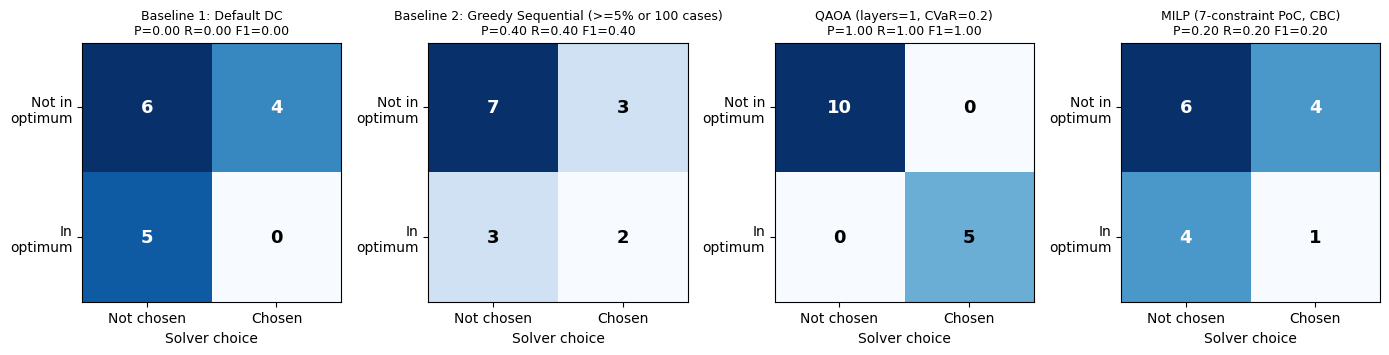

In [ ]:
def draw_confusion_grid(reports):
    # One 2x2 confusion matrix per solver
    optimum_positive = {i for i in reference.selected
                        if not instance.columns[i].is_unassigned}
    all_columns = {i for i in range(instance.n_vars)
                   if not instance.columns[i].is_unassigned}

    n = len(reports)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.5))
    if n == 1:
        axes = [axes]

    for ax, report in zip(axes, reports):
        predicted_positive = {i for i in report.solution.selected
                              if not instance.columns[i].is_unassigned}
        tp = len(predicted_positive & optimum_positive)
        fp = len(predicted_positive - optimum_positive)
        fn = len(optimum_positive - predicted_positive)
        tn = len(all_columns) - tp - fp - fn
        matrix = np.array([[tn, fp], [fn, tp]])
        ax.imshow(matrix, cmap="Blues", aspect="equal")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                        color="white" if matrix[i, j] > matrix.max()/1.8 else "black",
                        fontweight="bold", fontsize=13)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Not chosen", "Chosen"])
        ax.set_yticklabels(["Not in\noptimum", "In\noptimum"])
        ax.set_xlabel("Solver choice")
        prf = recovery_prf(instance, report.solution, reference)
        ax.set_title(f"{report.name}\nP={prf['precision']:.2f} "
                     f"R={prf['recall']:.2f} F1={prf['f1']:.2f}", fontsize=9)
    plt.tight_layout()
    plt.show()

draw_confusion_grid([baseline1, baseline2, best_qaoa, milp_report])


In [ ]:
# Multi-seed run: QAOA across 5 seeds, MILP is deterministic (one run)
SEEDS = (1, 7, 13, 42, 101)

# MILP once
milp_prf = recovery_prf(instance, milp_report.solution, reference)
milp_row = {
    "solver": "MILP",
    "objective": milp_report.solution.profit,
    "opt_gap_%": 100 * (reference.profit - milp_report.solution.profit) / abs(reference.profit),
    "precision": milp_prf["precision"],
    "recall": milp_prf["recall"],
    "f1": milp_prf["f1"],
    "runtime_s": milp_report.runtime_s,
}

seed_rows = []
for seed in SEEDS:
    q_report = run_qaoa(instance, qubo,
                        QaoaConfig(layers=2, shots=2048, cvar_alpha=0.20,
                                   maxiter=30, seed=seed))
    prf = recovery_prf(instance, q_report.solution, reference)
    seed_rows.append({
        "seed": seed, "solver": "QAOA",
        "objective": q_report.solution.profit,
        "opt_gap_%": 100 * (reference.profit - q_report.solution.profit) / abs(reference.profit),
        "precision": prf["precision"], "recall": prf["recall"], "f1": prf["f1"],
        "runtime_s": q_report.runtime_s,
    })
    seed_rows.append({**milp_row, "seed": seed})

robustness = pd.DataFrame(seed_rows)
print("Per-seed results:")
display(robustness.round(3))

print("\nAggregated across seeds:")
summary = robustness.groupby("solver").agg(
    obj_mean=("objective", "mean"), obj_std=("objective", "std"),
    P_mean=("precision", "mean"), P_std=("precision", "std"),
    R_mean=("recall", "mean"), R_std=("recall", "std"),
    F1_mean=("f1", "mean"), F1_std=("f1", "std"),
).round(3)
display(summary)

save_result(robustness, "robustness")
save_result(summary.reset_index(), "robustness_summary")


Per-seed results:


,seed,solver,objective,opt_gap_%,precision,recall,f1,runtime_s
0,1,QAOA,573128.529,0.000,1.0,1.0,1.0,31.614
1,1,MILP,549146.556,4.184,0.2,0.2,0.2,1.408
2,7,QAOA,573128.529,0.000,1.0,1.0,1.0,31.719
3,7,MILP,549146.556,4.184,0.2,0.2,0.2,1.408
4,13,QAOA,573128.529,0.000,1.0,1.0,1.0,30.662
5,13,MILP,549146.556,4.184,0.2,0.2,0.2,1.408
6,42,QAOA,573128.529,0.000,1.0,1.0,1.0,30.552
7,42,MILP,549146.556,4.184,0.2,0.2,0.2,1.408
8,101,QAOA,573128.529,0.000,1.0,1.0,1.0,30.216
9,101,MILP,549146.556,4.184,0.2,0.2,0.2,1.408



Aggregated across seeds:


,obj_mean,obj_std,P_mean,P_std,R_mean,R_std,F1_mean,F1_std
solver,,,,,,,,
MILP,549146.556,0.0,0.2,0.0,0.2,0.0,0.2,0.0
QAOA,573128.529,0.0,1.0,0.0,1.0,0.0,1.0,0.0


Saved  10 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/robustness_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/robustness_all_dates.csv  (5 date(s), 50 total rows)
Saved   2 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/robustness_summary_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/robustness_summary_all_dates.csv  (5 date(s), 10 total rows)


,date,solver,obj_mean,obj_std,P_mean,P_std,R_mean,R_std,F1_mean,F1_std
0,2024-06-17,MILP,980969.858,0.000,1.0,0.0,0.80,0.000,0.889,0.00
1,2024-06-17,QAOA,982776.519,0.000,1.0,0.0,1.00,0.000,1.000,0.00
2,2024-06-19,MILP,981093.361,0.000,1.0,0.0,0.80,0.000,0.889,0.00
3,2024-06-19,QAOA,982537.502,807.299,1.0,0.0,0.96,0.089,0.978,0.05
4,2024-06-21,MILP,981207.214,0.000,1.0,0.0,0.80,0.000,0.889,0.00
5,2024-06-21,QAOA,982650.261,806.687,1.0,0.0,0.96,0.089,0.978,0.05
6,2024-06-23,MILP,981148.886,0.000,1.0,0.0,0.80,0.000,0.889,0.00
7,2024-06-23,QAOA,982953.395,0.000,1.0,0.0,1.00,0.000,1.000,0.00
8,2024-06-25,MILP,549146.556,0.000,0.2,0.0,0.20,0.000,0.200,0.00
9,2024-06-25,QAOA,573128.529,0.000,1.0,0.0,1.00,0.000,1.000,0.00


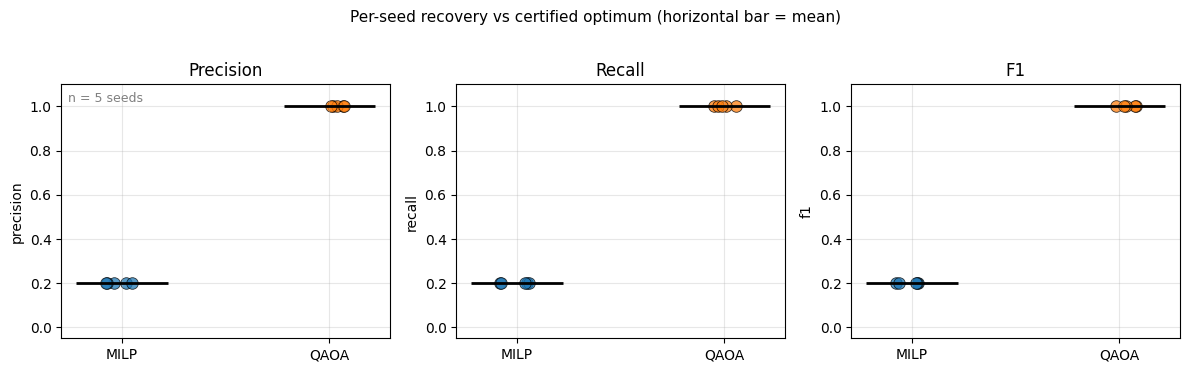

In [ ]:
# Scatter plot: precision, recall, F1 across seeds per solver
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
metrics = ["precision", "recall", "f1"]
solvers = sorted(robustness["solver"].unique())
jitter = np.random.default_rng(0)

for ax, metric in zip(axes, metrics):
    for i, solver in enumerate(solvers):
        values = robustness[robustness["solver"] == solver][metric].to_numpy()
        x = jitter.uniform(i - 0.08, i + 0.08, len(values))
        ax.scatter(x, values, s=70, alpha=0.75, edgecolor="k", linewidth=0.6)
        ax.hlines(values.mean(), i - 0.22, i + 0.22, colors="black", lw=2)
    ax.set_xticks(range(len(solvers)))
    ax.set_xticklabels(solvers)
    ax.set_ylabel(metric)
    ax.set_ylim(-0.05, 1.10)
    ax.set_title(metric.capitalize())
    ax.grid(alpha=0.3)

axes[0].text(0.02, 0.97, f"n = {len(SEEDS)} seeds", transform=axes[0].transAxes,
             va="top", fontsize=9, color="gray")
plt.suptitle("Per-seed recovery vs certified optimum (horizontal bar = mean)",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


## Scaling and noise

**Qubit scaling** - QAOA qubits grow as `n_orders × (n_alternates + 2)`.
Free Colab statevector runs top out around 22 qubits (≈5 orders). MILP has
no such ceiling.

**Depolarizing noise** on real hardware breaks the XY mixer's "exactly one
column per order" property. This cell measures how much amplitude leaks out
of the valid subspace as noise increases.


In [ ]:
# Qubit scaling table
scaling = pd.DataFrame([{
    "orders": k,
    **qubit_scaling(k, cfg.n_alternates, len(get_capacity_rows(instance))),
} for k in (5, 10, 25, 82, 426)])

# Statevector size overflows past ~60 qubits — cap for display
q = scaling["qubits_unbalanced_penalty"].to_numpy()
scaling["statevector_GiB"] = np.where(
    q <= 60, 2.0 ** np.minimum(q, 60) * 16 / 2**30, np.inf)

display(scaling.style.format({
    "classical_search_space": "{:.3g}",
    "statevector_GiB": "{:.3g}",
}))

save_result(scaling, "qubit_scaling")


,orders,columns_per_order,qubits_unbalanced_penalty,qubits_with_slack,classical_search_space,statevector_GiB
0,5,4,20,1268,1.02e+03,0.0156
1,10,4,40,1288,1.05e+06,1.64e+04
2,25,4,100,1348,1.13e+15,inf
3,82,4,328,1576,2.34e+49,inf
4,426,4,1704,2952,3e+256,inf


Saved   5 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/qubit_scaling_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/qubit_scaling_all_dates.csv  (5 date(s), 25 total rows)


,date,orders,columns_per_order,qubits_unbalanced_penalty,qubits_with_slack,classical_search_space,statevector_GiB
0,2024-06-17,5,4,20,2024,1024,1.562500e-02
1,2024-06-17,10,4,40,2044,1048576,1.638400e+04
2,2024-06-17,25,4,100,2104,1125899906842624,inf
3,2024-06-17,82,4,328,2332,2338402619729444669125895732346052831449492068...,inf
4,2024-06-17,426,4,1704,3708,3003006731521880091988463078203702744524703837...,inf
5,2024-06-19,5,4,20,2024,1024,1.562500e-02
6,2024-06-19,10,4,40,2044,1048576,1.638400e+04
7,2024-06-19,25,4,100,2104,1125899906842624,inf
8,2024-06-19,82,4,328,2332,2338402619729444669125895732346052831449492068...,inf
9,2024-06-19,426,4,1704,3708,3003006731521880091988463078203702744524703837...,inf


In [ ]:
# Noise study on a smaller instance (12 qubits)
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2

cfg_small = SubinstanceConfig(current_date=cfg.current_date, n_orders=3, n_alternates=2)
inst_small = build_instance(data, focus, cfg_small)
qubo_small = build_qubo(inst_small, PenaltyWeights(one_hot=0.0))
circuit_small, params_small = build_qaoa_circuit(
    inst_small, qubo_small, QaoaConfig(layers=2))
bound = transpile(circuit_small, AerSimulator(), optimization_level=1
                 ).assign_parameters(dict(zip(params_small, [0.6, 0.4, 0.9, 0.3])))

noise_rows = []
for p_2q in (0.0, 1e-3, 5e-3, 2e-2):
    noise_model = NoiseModel()
    if p_2q > 0:
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(p_2q, 2), ["rzz", "rxx", "ryy", "cx"])
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(p_2q/10, 1), ["u3", "rz", "sx", "x"])
    counts = SamplerV2(
        seed=SEED, options={"backend_options": {"noise_model": noise_model}}
    ).run([bound], shots=512).result()[0].data.c.get_counts()
    total = sum(counts.values())
    solutions_by_bits = {b: decode(inst_small, bits_to_array(b, inst_small.n_vars))
                         for b in counts}
    in_subspace = sum(c for b, c in counts.items()
                      if not any("one-hot" in v
                                 for v in solutions_by_bits[b].violations)) / total
    feasible = sum(c for b, c in counts.items()
                   if solutions_by_bits[b].feasible) / total
    noise_rows.append({
        "two_qubit_error": p_2q,
        "unique_bitstrings": len(counts),
        "in_onehot_subspace_%": 100 * in_subspace,
        "feasible_%": 100 * feasible,
    })

noise_study = pd.DataFrame(noise_rows).round(2)
save_result(noise_study, "noise_study")
noise_study


Saved   4 row(s) -> /content/drive/MyDrive/nestle_dom_data/results/noise_study_2024-06-25.csv
Updated cumulative file  -> /content/drive/MyDrive/nestle_dom_data/results/noise_study_all_dates.csv  (5 date(s), 20 total rows)


,two_qubit_error,unique_bitstrings,in_onehot_subspace_%,feasible_%
0,0.00,56,100.00,70.90
1,0.00,87,94.34,65.43
2,0.00,157,77.34,54.30
3,0.02,295,38.09,25.59


## Cross-date comparison

Reads back everything saved in `results/*_all_dates.csv` and compares
the target dates side by side.


In [ ]:
TARGET_DATES = ["2024-06-17", "2024-06-19", "2024-06-21", "2024-06-23", "2024-06-25"]

def load_all(name):
    path = os.path.join(RESULTS_DIR, f"{name}_all_dates.csv")
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    return df[df["date"].isin(TARGET_DATES)]

run_summary_all = load_all("run_summary")
comparison_all = load_all("comparison")
order_level_all = load_all("order_level")
robustness_all = load_all("robustness")
robustness_summary_all = load_all("robustness_summary")
scaling_all = load_all("qubit_scaling")

dates_done = sorted(run_summary_all["date"].unique()) if len(run_summary_all) else []
missing = [d for d in TARGET_DATES if d not in dates_done]
print(f"Dates with saved results : {dates_done}")
if missing:
    print(f"Still missing            : {missing}  "
          f"(set cfg.current_date to each and rerun the notebook)")

print("\nRun-level summary across dates:")
display(run_summary_all.sort_values("date") if len(run_summary_all) else run_summary_all)

print("\nSolver comparison across dates:")
display(comparison_all.sort_values(["date", "solver"]) if len(comparison_all) else comparison_all)


Dates with saved results : ['2024-06-17', '2024-06-19', '2024-06-21', '2024-06-23', '2024-06-25']

Run-level summary across dates:


,date,n_orders,n_qubits,certified_optimum_profit,certified_optimum_fill_rate,n_combinations_evaluated,exact_solve_time_s,baseline1_profit,baseline2_profit,best_qaoa_layers,best_qaoa_profit,best_qaoa_runtime_s,milp_status,milp_profit,milp_runtime_s
0,2024-06-17,5,20,982776.518927,0.889850,1024,1.566586,118064.977742,980969.857742,"QAOA (layers=1, CVaR=0.2)",982776.518927,16.100203,Optimal,980969.857742,0.684116
1,2024-06-19,5,20,982898.537061,0.889850,1024,2.894706,118188.480524,981093.360524,"QAOA (layers=1, CVaR=0.2)",982898.537061,15.702954,Optimal,981093.360524,0.685754
2,2024-06-21,5,20,983011.022338,0.889850,1024,2.338072,118302.334459,981207.214459,"QAOA (layers=1, CVaR=0.2)",983011.022338,16.187786,Optimal,981207.214459,0.700675
3,2024-06-23,5,20,982953.394804,0.889850,1024,1.545497,118244.005745,981148.885745,"QAOA (layers=1, CVaR=0.2)",982953.394804,16.017437,Optimal,981148.885745,0.699378
4,2024-06-25,5,20,573128.529412,0.891099,1024,1.927403,436523.396190,555652.195840,"QAOA (layers=1, CVaR=0.2)",573128.529412,15.085636,Optimal,549146.555840,1.408009



Solver comparison across dates:


,date,solver,objective,opt_gap_%,revenue,shipping,penalty,fill_rate,diverts,feasible_sample_%,runtime_s,precision,recall,f1
0,2024-06-17,Baseline 1: Default DC,118064.977742,87.986589,152015.000000,770.0,33180.022258,0.086198,0,100.000000,0.007809,0.0,0.0,0.000000
1,2024-06-17,Baseline 2: Greedy Sequential (>=5% or 100 cases),980969.857742,0.183832,992440.000000,7339.0,4131.142258,0.887964,4,100.000000,0.008868,1.0,0.8,0.888889
3,2024-06-17,"MILP (7-constraint PoC, CBC)",980969.857742,0.183832,992440.000000,7339.0,4131.142258,0.887964,4,100.000000,0.684116,1.0,0.8,0.888889
2,2024-06-17,"QAOA (layers=1, CVaR=0.2)",982776.518927,0.000000,994461.000000,7603.0,4081.481073,0.889850,5,28.592122,16.100203,1.0,1.0,1.000000
4,2024-06-19,Baseline 1: Default DC,118188.480524,87.975516,152015.000000,770.0,33056.519476,0.086198,0,100.000000,0.004045,0.0,0.0,0.000000
5,2024-06-19,Baseline 2: Greedy Sequential (>=5% or 100 cases),981093.360524,0.183658,992440.000000,7339.0,4007.639476,0.887964,4,100.000000,0.003881,1.0,0.8,0.888889
7,2024-06-19,"MILP (7-constraint PoC, CBC)",981093.360524,0.183658,992440.000000,7339.0,4007.639476,0.887964,4,100.000000,0.685754,1.0,0.8,0.888889
6,2024-06-19,"QAOA (layers=1, CVaR=0.2)",982898.537061,0.000000,994461.000000,7603.0,3959.462939,0.889850,5,23.925781,15.702954,1.0,1.0,1.000000
8,2024-06-21,Baseline 1: Default DC,118302.334459,87.965309,152015.000000,770.0,32942.665541,0.086198,0,100.000000,0.003974,0.0,0.0,0.000000
9,2024-06-21,Baseline 2: Greedy Sequential (>=5% or 100 cases),981207.214459,0.183498,992440.000000,7339.0,3893.785541,0.887964,4,100.000000,0.004938,1.0,0.8,0.888889


##Cross-date Visualizations

Regenerates Graphical Figures using the cumulative CSVs. Each figure also saves to results/figures/ as PNG.

In [ ]:
#Setup — load CSVs and set up shared plots

import os
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Solver colour scheme (matches report)
SOLVER_COLOURS = {
    "Baseline 1: default DC": "#7f7f7f",
    "Baseline 2: greedy (>=5% or 100 cases)": "#1f77b4",
    "QAOA (layers=1, CVaR=0.2)": "#d62728",
    "QAOA (layers=2, CVaR=0.2)": "#d62728",
    "MILP (7-constraint PoC, CBC)": "#2ca02c",
    # Short names too
    "Baseline 1": "#7f7f7f", "Baseline 2": "#1f77b4",
    "QAOA": "#d62728", "MILP": "#2ca02c",
}

def _colour_for(solver_name):
    for key, colour in SOLVER_COLOURS.items():
        if solver_name.startswith(key) or key.startswith(solver_name):
            return colour
    return "#333333"

def _read_or_none(name):
    path = os.path.join(RESULTS_DIR, f"{name}_all_dates.csv")
    return pd.read_csv(path) if os.path.exists(path) else None

comparison = _read_or_none("comparison")
run_summary = _read_or_none("run_summary")
robustness = _read_or_none("robustness")
robustness_summary = _read_or_none("robustness_summary")
qubit_scaling_df = _read_or_none("qubit_scaling")
noise_study = _read_or_none("noise_study")

print("CSVs found:")
for name, df in [("comparison", comparison), ("run_summary", run_summary),
                 ("robustness", robustness), ("robustness_summary", robustness_summary),
                 ("qubit_scaling", qubit_scaling_df), ("noise_study", noise_study)]:
    print(f"  {'✓' if df is not None else '✗'} {name}_all_dates.csv"
          + (f"  ({len(df)} rows)" if df is not None else "  (skipping related figures)"))

CSVs found:
  ✓ comparison_all_dates.csv  (20 rows)
  ✓ run_summary_all_dates.csv  (5 rows)
  ✓ robustness_all_dates.csv  (50 rows)
  ✓ robustness_summary_all_dates.csv  (10 rows)
  ✓ qubit_scaling_all_dates.csv  (25 rows)
  ✓ noise_study_all_dates.csv  (20 rows)


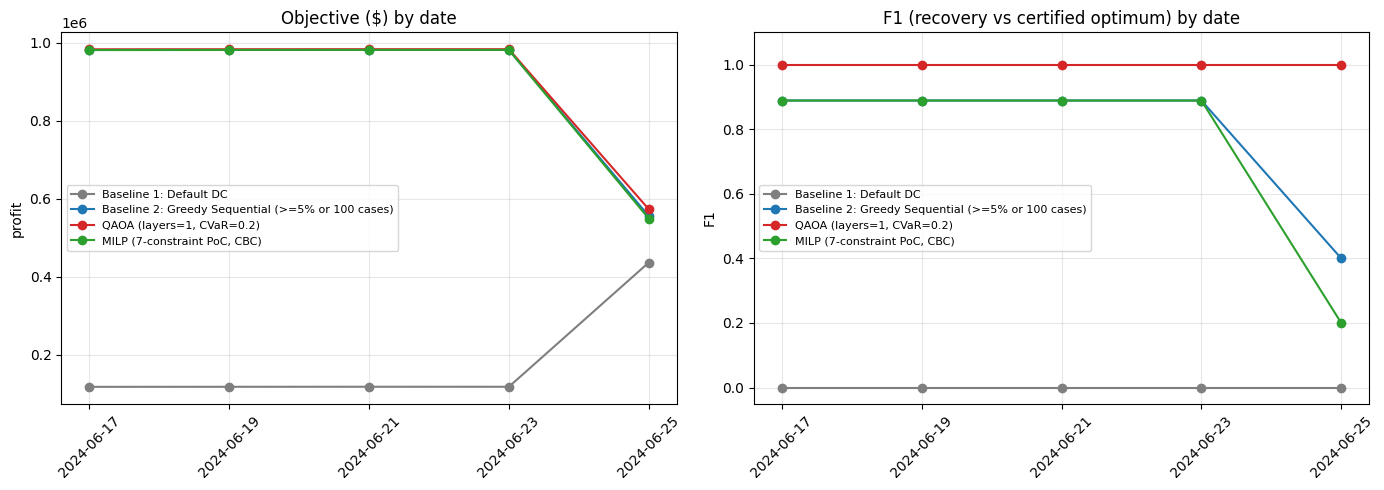

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig1_objective_and_f1.png


In [ ]:
# Figure 1 — Objective ($) and F1 by solver, across all dates

if comparison is None:
    print("Skipping — comparison_all_dates.csv not found.")
else:
    dates = sorted(comparison["date"].unique())
    solvers = comparison["solver"].unique()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for solver in solvers:
        rows = comparison[comparison["solver"] == solver].sort_values("date")
        colour = _colour_for(solver)
        ax1.plot(rows["date"], rows["objective"], marker="o", label=solver, color=colour)
        ax2.plot(rows["date"], rows["f1"], marker="o", label=solver, color=colour)

    ax1.set_title("Objective ($) by date")
    ax1.set_ylabel("profit")
    ax1.tick_params(axis="x", rotation=45)
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)

    ax2.set_title("F1 (recovery vs certified optimum) by date")
    ax2.set_ylabel("F1")
    ax2.set_ylim(-0.05, 1.10)
    ax2.tick_params(axis="x", rotation=45)
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig1_objective_and_f1.png"), dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig1_objective_and_f1.png")

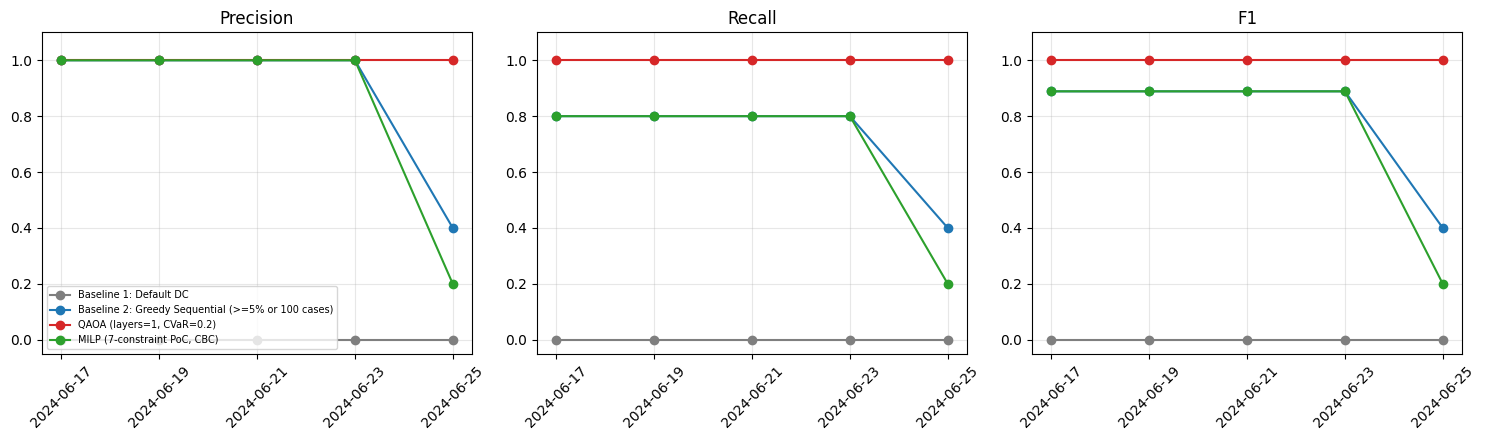

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig2_prf_by_date.png


In [ ]:
# Figure 2 — Precision, Recall, F1 by solver, across all dates

if comparison is None:
    print("Skipping — comparison_all_dates.csv not found.")
else:
    solvers = comparison["solver"].unique()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, metric in zip(axes, ["precision", "recall", "f1"]):
        for solver in solvers:
            rows = comparison[comparison["solver"] == solver].sort_values("date")
            colour = _colour_for(solver)
            ax.plot(rows["date"], rows[metric], marker="o", label=solver, color=colour)
        ax.set_title(metric.capitalize())
        ax.set_ylim(-0.05, 1.10)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=7, loc="lower left")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig2_prf_by_date.png"), dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig2_prf_by_date.png")

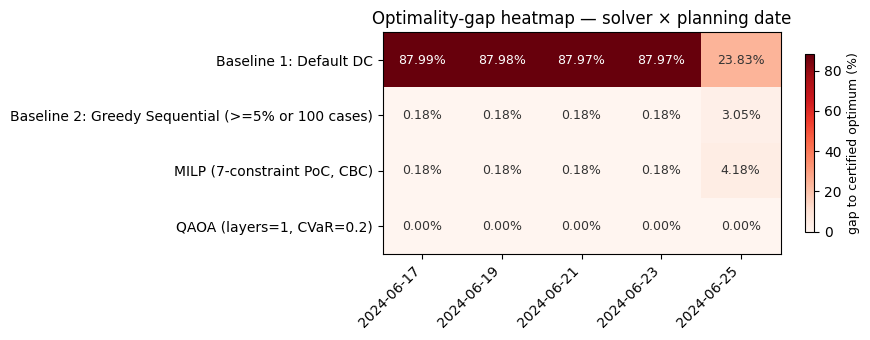

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig3_gap_heatmap.png


In [ ]:
# Figure 3 — Optimality-gap heatmap (solver × date)

import numpy as np

if comparison is None:
    print("Skipping — comparison_all_dates.csv not found.")
else:
    pivot = comparison.pivot(index="solver", columns="date", values="opt_gap_%")

    fig, ax = plt.subplots(figsize=(9, 3.5))
    im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # Annotate each cell with the percentage value
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            colour = "white" if val > pivot.values.max() / 2 else "#333"
            ax.text(j, i, f"{val:.2f}%", ha="center", va="center",
                    color=colour, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("gap to certified optimum (%)", fontsize=9)
    ax.set_title("Optimality-gap heatmap — solver × planning date")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig3_gap_heatmap.png"), dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig3_gap_heatmap.png")

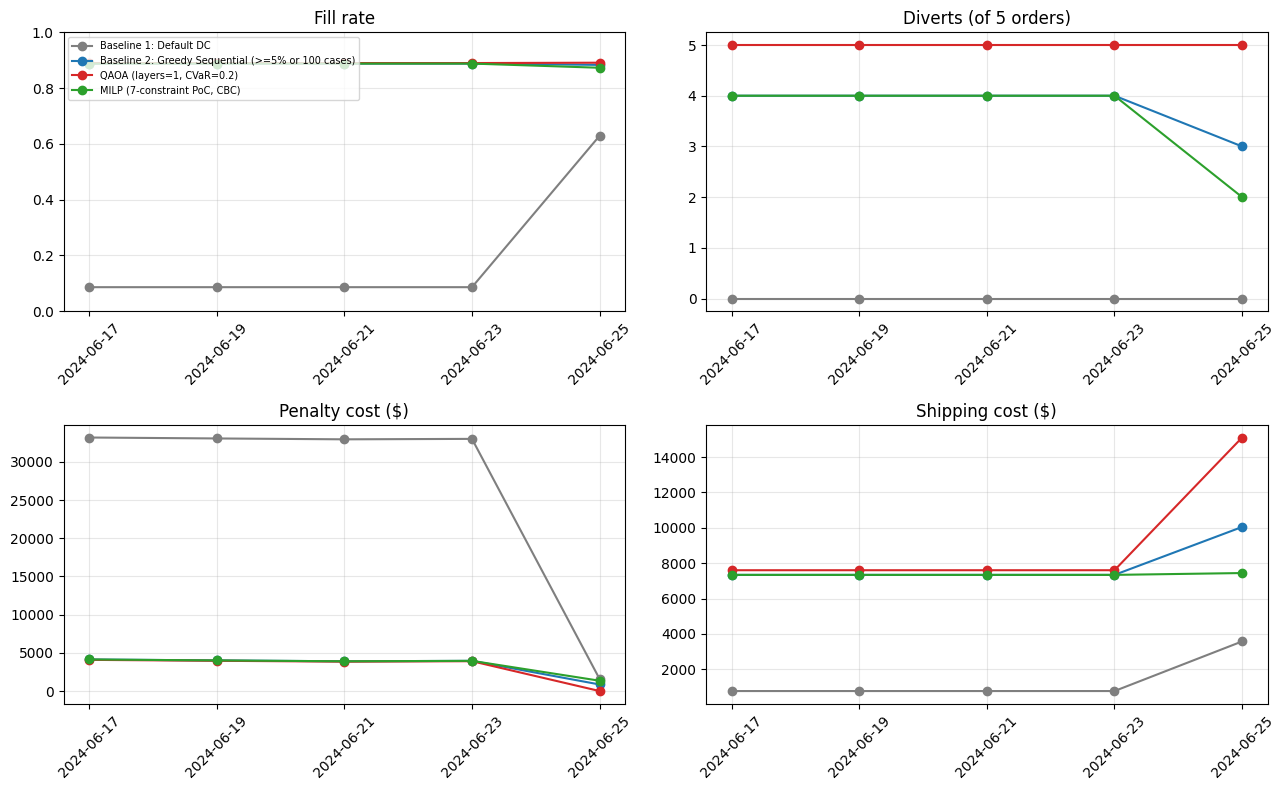

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig4_fill_diverts_penalty_shipping.png


In [ ]:
# Figure 4 — Fill / diverts / penalty / shipping by solver, by date

if comparison is None:
    print("Skipping — comparison_all_dates.csv not found.")
else:
    solvers = comparison["solver"].unique()
    metrics = [
        ("fill_rate", "Fill rate", "{:.0%}", (0, 1.0)),
        ("diverts", "Diverts (of 5 orders)", "{:.0f}", None),
        ("penalty", "Penalty cost ($)", "${:,.0f}", None),
        ("shipping", "Shipping cost ($)", "${:,.0f}", None),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, (col, title, _fmt, ylim) in zip(axes.flat, metrics):
        if col not in comparison.columns:
            ax.text(0.5, 0.5, f"'{col}' not in CSV", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10, color="#999")
            ax.set_title(title)
            continue
        for solver in solvers:
            rows = comparison[comparison["solver"] == solver].sort_values("date")
            colour = _colour_for(solver)
            ax.plot(rows["date"], rows[col], marker="o", label=solver, color=colour)
        ax.set_title(title)
        if ylim: ax.set_ylim(*ylim)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)
    axes[0, 0].legend(fontsize=7, loc="upper left")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig4_fill_diverts_penalty_shipping.png"),
                dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig4_fill_diverts_penalty_shipping.png")

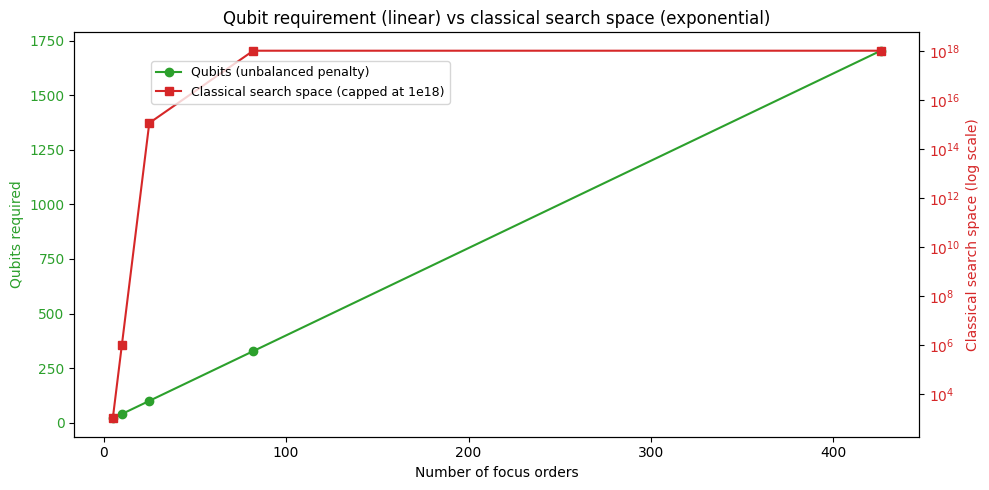

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig5_qubit_scaling.png


In [ ]:
#Figure 5 — Qubit requirement vs classical search-space size

if qubit_scaling_df is None:
    print("Skipping — qubit_scaling_all_dates.csv not found.")
else:
    # De-dupe by orders (scaling is invariant to date) and sort
    df = qubit_scaling_df.drop_duplicates(subset=["orders"]).sort_values("orders").copy()

    # Coerce columns to numeric — pandas can save large ints or scientific notation
    # as strings depending on write path
    df["orders"] = pd.to_numeric(df["orders"], errors="coerce")
    df["qubits_unbalanced_penalty"] = pd.to_numeric(df["qubits_unbalanced_penalty"], errors="coerce")
    df["classical_search_space"] = pd.to_numeric(df["classical_search_space"], errors="coerce")
    df = df.dropna(subset=["orders", "qubits_unbalanced_penalty", "classical_search_space"])

    fig, ax_left = plt.subplots(figsize=(10, 5))
    ax_right = ax_left.twinx()

    ax_left.plot(df["orders"], df["qubits_unbalanced_penalty"],
                 marker="o", color="#2ca02c", label="Qubits (unbalanced penalty)")
    ax_left.set_xlabel("Number of focus orders")
    ax_left.set_ylabel("Qubits required", color="#2ca02c")
    ax_left.tick_params(axis="y", labelcolor="#2ca02c")

    # Cap the classical search space so the log plot doesn't explode
    y_class = df["classical_search_space"].clip(upper=1e18)
    ax_right.plot(df["orders"], y_class, marker="s", color="#d62728",
                  label="Classical search space (capped at 1e18)")
    ax_right.set_yscale("log")
    ax_right.set_ylabel("Classical search space (log scale)", color="#d62728")
    ax_right.tick_params(axis="y", labelcolor="#d62728")

    ax_left.set_title("Qubit requirement (linear) vs classical search space (exponential)")
    fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.88), fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig5_qubit_scaling.png"), dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig5_qubit_scaling.png")

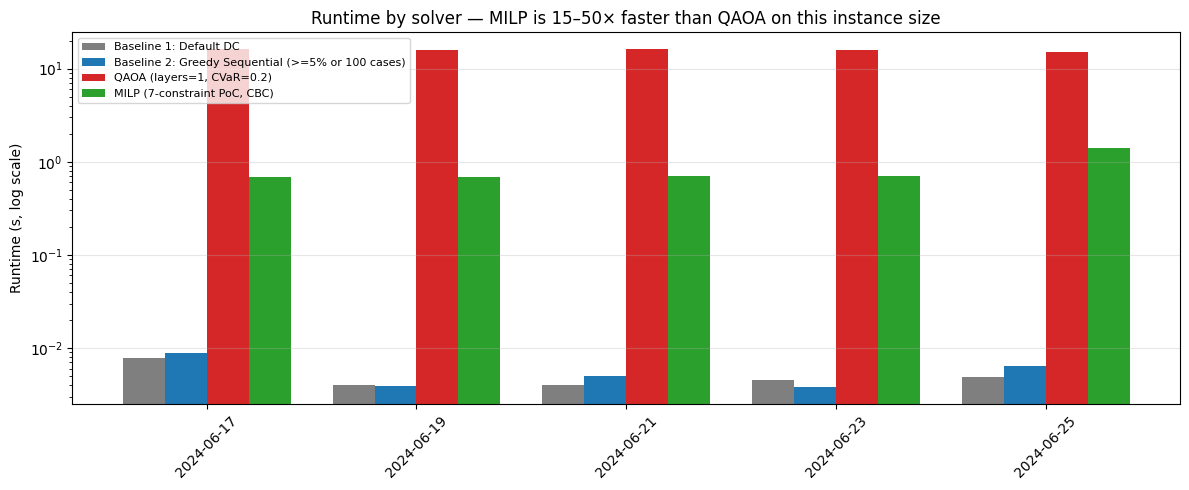

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig6_runtime.png


In [ ]:
# Figure 6 — Runtime (s, log scale) by solver × date

if comparison is None:
    print("Skipping — comparison_all_dates.csv not found.")
else:
    solvers = list(comparison["solver"].unique())
    dates = sorted(comparison["date"].unique())

    fig, ax = plt.subplots(figsize=(12, 5))
    n_solvers = len(solvers)
    bar_width = 0.8 / n_solvers
    x = np.arange(len(dates))

    for i, solver in enumerate(solvers):
        rows = comparison[comparison["solver"] == solver].set_index("date").reindex(dates)
        colour = _colour_for(solver)
        ax.bar(x + i * bar_width, rows["runtime_s"].fillna(0),
               width=bar_width, label=solver, color=colour)

    ax.set_yscale("log")
    ax.set_ylabel("Runtime (s, log scale)")
    ax.set_xticks(x + bar_width * (n_solvers - 1) / 2)
    ax.set_xticklabels(dates, rotation=45)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.set_title("Runtime by solver — MILP is 15–50× faster than QAOA on this instance size")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig6_runtime.png"), dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig6_runtime.png")

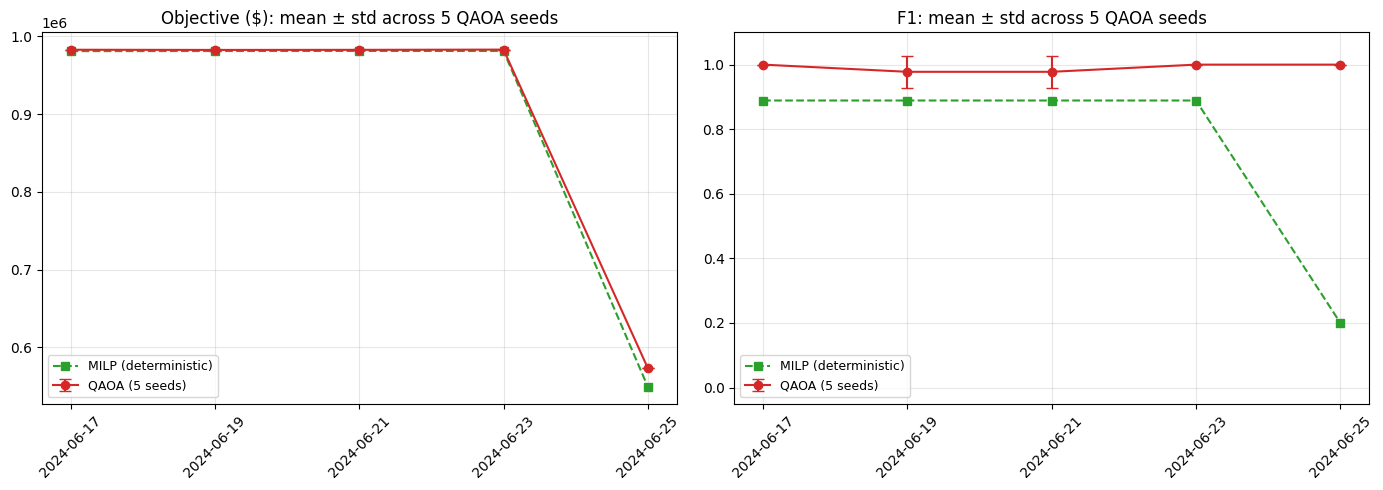

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig7_multi_seed_robustness.png


In [ ]:
# Figure 7 — QAOA objective & F1 with error bars vs deterministic MILP

if robustness is None or robustness_summary is None:
    print("Skipping — robustness_all_dates.csv or robustness_summary_all_dates.csv not found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, title in zip(
        axes, ["objective", "f1"],
        ["Objective ($): mean ± std across 5 QAOA seeds",
         "F1: mean ± std across 5 QAOA seeds"],
    ):
        # QAOA — mean ± std from summary
        qaoa_rows = robustness_summary[robustness_summary["solver"] == "QAOA"].sort_values("date")
        milp_rows = robustness_summary[robustness_summary["solver"] == "MILP"].sort_values("date")
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col not in qaoa_rows.columns:
            # Fall back to per-seed data if summary lacks the columns
            qaoa_stats = (robustness[robustness["solver"] == "QAOA"]
                          .groupby("date")[metric].agg(["mean", "std"]).reset_index())
            milp_stats = (robustness[robustness["solver"] == "MILP"]
                          .groupby("date")[metric].agg(["mean", "std"]).reset_index())
            qaoa_rows, milp_rows = qaoa_stats, milp_stats
            mean_col, std_col = "mean", "std"

        ax.errorbar(qaoa_rows["date"], qaoa_rows[mean_col], yerr=qaoa_rows[std_col],
                    marker="o", capsize=4, color="#d62728", label="QAOA (5 seeds)")
        ax.plot(milp_rows["date"], milp_rows[mean_col], marker="s", linestyle="--",
                color="#2ca02c", label="MILP (deterministic)")
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
        if metric == "f1":
            ax.set_ylim(-0.05, 1.10)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "fig7_multi_seed_robustness.png"),
                dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig7_multi_seed_robustness.png")

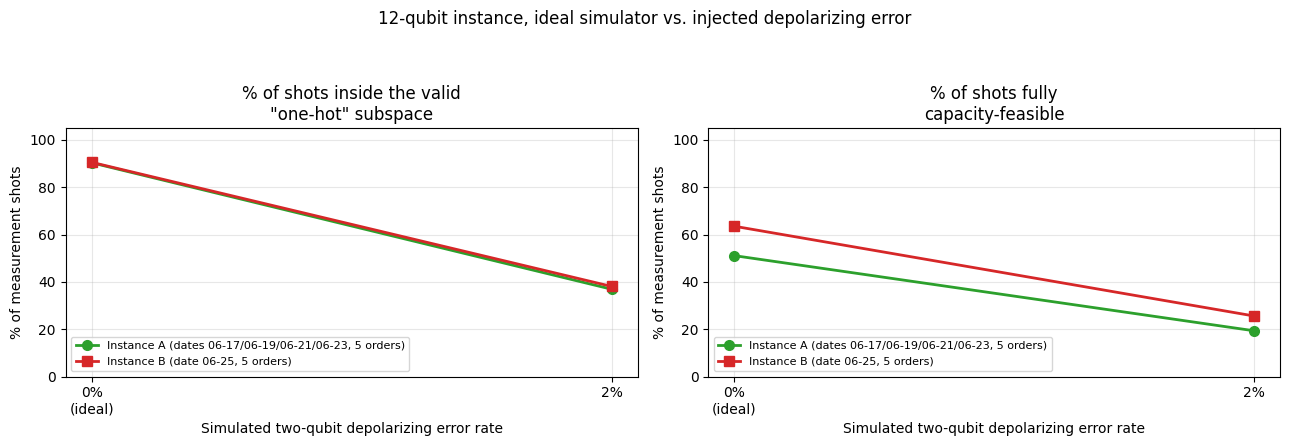

Saved: /content/drive/MyDrive/nestle_dom_data/results/figures/fig8_noise_sensitivity.png


In [ ]:
# Figure 8 — Depolarizing-noise sensitivity on QAOA

if noise_study is None:
    print("Skipping — noise_study_all_dates.csv not found.")
else:
    df = noise_study.copy()
    INSTANCE_GROUPS = {
        "A": {"dates": ["2024-06-17", "2024-06-19", "2024-06-21", "2024-06-23"],
              "orders": 5, "colour": "#2ca02c", "marker": "o"},
        "B": {"dates": ["2024-06-25"],
              "orders": 5, "colour": "#d62728", "marker": "s"},
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(
        "12-qubit instance, ideal simulator vs. injected depolarizing error",
        fontsize=12,
    )

    noise_levels = sorted(df["two_qubit_error"].unique())
    x_pos = list(range(len(noise_levels)))

    def _label(v):
        return "0%\n(ideal)" if v == 0 else f"{v*100:g}%"

    for name, cfg in INSTANCE_GROUPS.items():
        sub = df[df["date"].isin(cfg["dates"])]
        if sub.empty:
            continue
        # average across repeated dates within the group, in noise-level order
        grouped = (sub.groupby("two_qubit_error")[["in_onehot_subspace_%", "feasible_%"]]
                      .mean()
                      .reindex(noise_levels))

        date_str = "/".join(d[5:].replace("-", "-") for d in cfg["dates"])  # e.g. 06-17/06-19/...
        date_str = "/".join(d[5:] for d in cfg["dates"])                    # -> 06-17/06-19/06-21/06-23
        label = f"Instance {name} (date{'s' if len(cfg['dates'])>1 else ''} {date_str}, {cfg['orders']} orders)"

        ax1.plot(x_pos, grouped["in_onehot_subspace_%"], marker=cfg["marker"],
                  label=label, color=cfg["colour"], linewidth=2, markersize=7)
        ax2.plot(x_pos, grouped["feasible_%"], marker=cfg["marker"],
                  label=label, color=cfg["colour"], linewidth=2, markersize=7)

    for ax, title in [(ax1, "% of shots inside the valid\n\"one-hot\" subspace"),
                       (ax2, "% of shots fully\ncapacity-feasible")]:
        ax.set_xticks(x_pos)
        ax.set_xticklabels([_label(v) for v in noise_levels])
        ax.set_xlabel("Simulated two-qubit depolarizing error rate")
        ax.set_ylabel("% of measurement shots")
        ax.set_title(title)
        ax.set_ylim(0, 105)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="lower left")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(os.path.join(FIG_DIR, "fig8_noise_sensitivity.png"),
                dpi=140, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIG_DIR}/fig8_noise_sensitivity.png")